# Machine Learning Project — Premier League Match Analysis

---

## 1. Problem Definition

### Dataset
The dataset used in this project contains **4,788 Premier League matches** 
from the **2019–2024 seasons**, with 28 features per match including 
team statistics, match context, and performance metrics.

**Source:** [Premier League Matches Dataset — Kaggle](https://www.kaggle.com/datasets/ajaxianazarenka/premier-league)

---

### Classification Problem

**What are we predicting?**  
The result of a Premier League match from the perspective of a given team.

**Target variable:** `result`  
**Classes:**
| Class | Meaning |
|-------|---------|
| **W** | The team won the match |
| **D** | The match ended in a draw |
| **L** | The team lost the match |

**Input features:** venue (home/away), xG, possession, shots, 
shots on target, goals conceded, opponent, formation, season.

**Practical relevance:**  
Predicting match outcomes has direct applications in sports analytics, 
betting markets, and team performance evaluation. 
Understanding which factors most influence a win can help 
coaches and analysts make better tactical decisions.

**Why this problem?**  
Football match prediction is a well-studied problem in sports analytics. 
The Premier League is the most competitive and data-rich football league 
in the world, making it an ideal environment for applying 
and comparing machine learning models.

---

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual settings
sns.set_theme(style="whitegrid") # Set Seaborn theme for better aesthetics
plt.rcParams['figure.figsize'] = (10, 5) # Set default figure size for plots

df = pd.read_csv('../datasets/premier-league-matches.csv')
print("Data loaded successfully!")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

Data loaded successfully!
Dataset shape: 4788 rows, 28 columns


## 2. First Look at the Data

Before any analysis, we inspect the general structure 
of the dataset: columns, data types, and first records.

In [30]:
# First 5 rows
display(df.head())

# Data types
print("\nData types:")
print(df.dtypes)

# General statistics
print("\nDescriptive statistics:")
display(df[['gf','ga','xg','xga','poss','sh','sot']].describe().round(2))

,Unnamed: 0,date,time,comp,round,day,venue,result,gf,ga,...,match report,notes,sh,sot,dist,fk,pk,pkatt,season,team
0,0,2020-09-21,20:15 (21:15),Premier League,Matchweek 2,Mon,Away,W,3,1,...,Match Report,NaN,13,8,21.1,2,1,1,2024,Manchester City
1,2,2020-09-27,16:30 (17:30),Premier League,Matchweek 3,Sun,Home,L,2,5,...,Match Report,NaN,16,5,19.8,1,0,0,2024,Manchester City
2,4,2020-10-03,17:30 (18:30),Premier League,Matchweek 4,Sat,Away,D,1,1,...,Match Report,NaN,23,1,18.2,1,0,0,2024,Manchester City
3,5,2020-10-17,17:30 (18:30),Premier League,Matchweek 5,Sat,Home,W,1,0,...,Match Report,NaN,13,5,17.7,0,0,0,2024,Manchester City
4,7,2020-10-24,12:30 (13:30),Premier League,Matchweek 6,Sat,Away,D,1,1,...,Match Report,NaN,14,7,20.9,1,0,0,2024,Manchester City



Data types:
Unnamed: 0        int64
date                str
time                str
comp                str
round               str
day                 str
venue               str
result              str
gf                int64
ga                int64
opponent            str
xg              float64
xga             float64
poss              int64
attendance      float64
captain             str
formation           str
referee             str
match report        str
notes           float64
sh                int64
sot               int64
dist            float64
fk                int64
pk                int64
pkatt             int64
season            int64
team                str
dtype: object

Descriptive statistics:


,gf,ga,xg,xga,poss,sh,sot
count,4788.00,4788.00,4788.00,4788.00,4788.00,4788.00,4788.00
mean,1.45,1.41,1.40,1.36,50.43,12.62,4.26
std,1.31,1.29,0.83,0.81,12.81,5.55,2.46
min,0.00,0.00,0.00,0.00,18.00,0.00,0.00
25%,0.00,0.00,0.80,0.70,41.00,9.00,2.00
50%,1.00,1.00,1.30,1.20,51.00,12.00,4.00
75%,2.00,2.00,1.90,1.80,60.00,16.00,6.00
max,9.00,9.00,7.00,7.00,82.00,36.00,15.00


### Performance Statistics — Column Descriptions

| Column | Full Name | Description |
|--------|-----------|-------------|
| `gf` | Goals For | Number of goals scored by the team |
| `ga` | Goals Against | Number of goals conceded by the team |
| `xg` | Expected Goals | Statistical estimate of goals expected based on shot quality |
| `xga` | Expected Goals Against | Expected goals conceded based on opponent shot quality |
| `poss` | Possession | Percentage of ball possession |
| `sh` | Shots | Total shots attempted |
| `sot` | Shots on Target | Shots that were directed on target |
| `dist` | Average Shot Distance | Average distance of shots from goal (in yards) |
| `fk` | Free Kicks | Shots taken from free kicks |
| `pk` | Penalty Kicks Scored | Goals scored from the penalty spot |
| `pkatt` | Penalty Kicks Attempted | Total penalty kicks attempted |

### Initial Observations

- The dataset covers **5 seasons** (2019–2024)
- `gf` and `ga` represent goals scored and conceded
- `xg` and `xga` = **expected goals** - a statistical estimate 
  of goals expected based on shot quality
- `poss` = team possession percentage
- `gf` values range between 0 and 9 goals per match

## 3. Data Quality

We check for missing values, duplicates, 
and irrelevant columns.

In [31]:
# Missing values
print("Missing values per column:")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

# Missing percentage
print("\nMissing value percentage:")
print((missing / len(df) * 100).round(2))

# Duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Irrelevant columns
print("\nColumns to drop: 'notes', 'Unnamed: 0', 'match report'")

Missing values per column:
attendance    1633
notes         4788
dist             2
dtype: int64

Missing value percentage:
attendance     34.11
notes         100.00
dist            0.04
dtype: float64

Duplicate rows: 0

Columns to drop: 'notes', 'Unnamed: 0', 'match report'


### Data Quality Conclusions

- **`attendance`** is missing in ~34% of cases - 
  likely matches played without fans (COVID-19, 2020–2021).
  We will either exclude it or impute with the median.
- **`dist`** is missing in only 2 rows - negligible, 
  we will drop those rows.
- **`notes`** is entirely empty - we will drop this column.
- **Zero duplicates** - clean dataset 

## 4. Distribution Analysis

We analyze the distribution of numerical and 
categorical variables to understand the data structure.

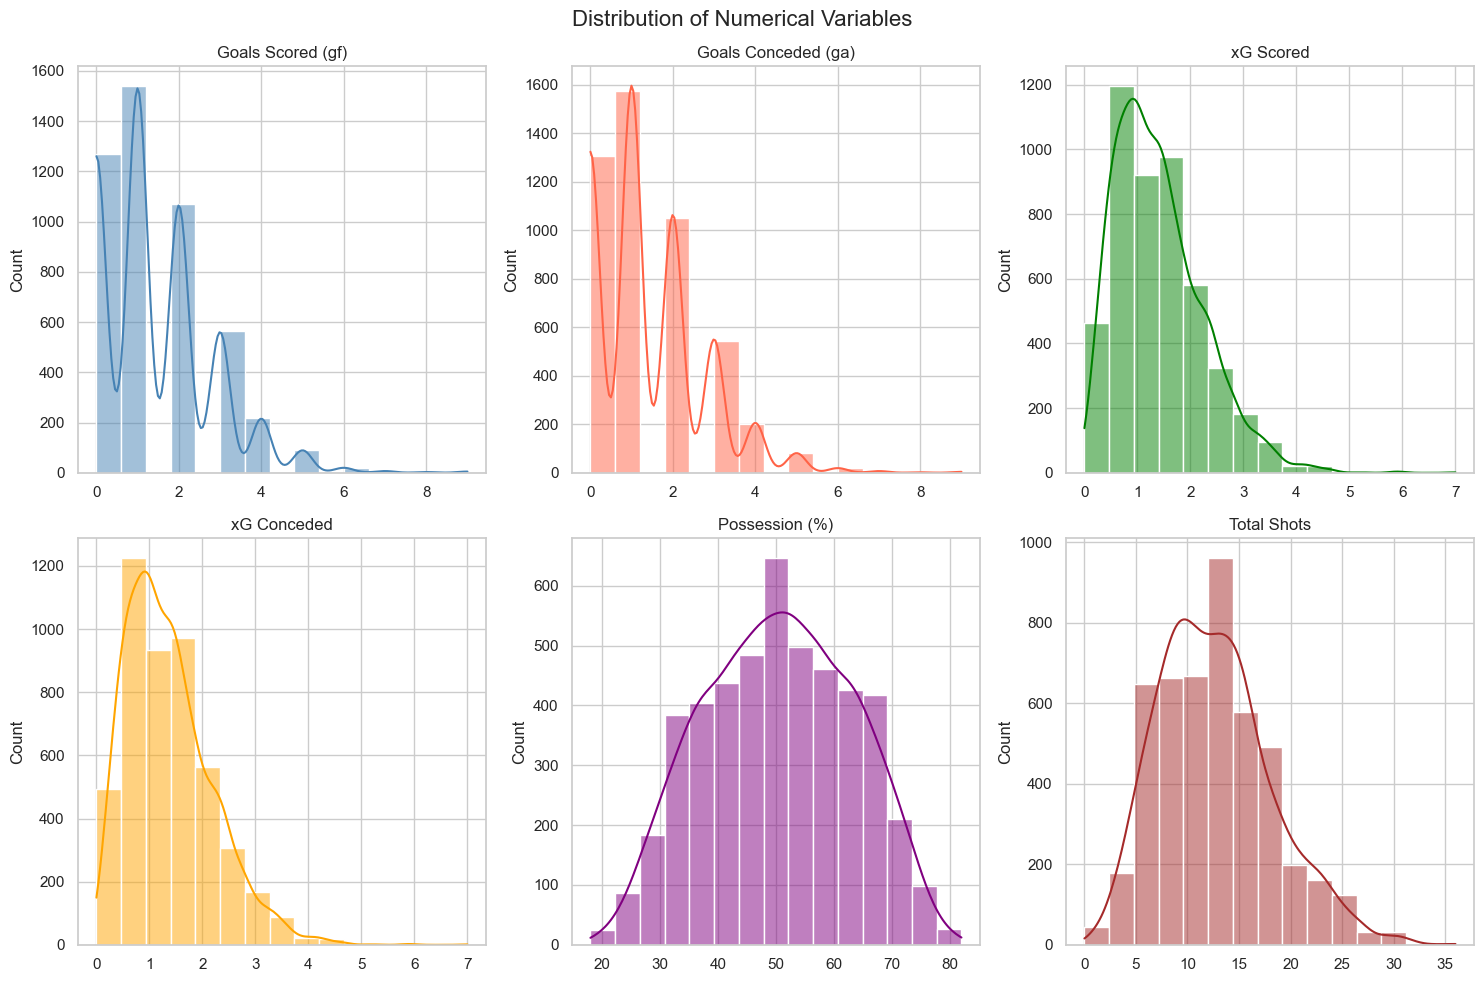

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Numerical Variables', fontsize=16)

cols = ['gf', 'ga', 'xg', 'xga', 'poss', 'sh']
titles = ['Goals Scored (gf)', 'Goals Conceded (ga)',
          'xG Scored', 'xG Conceded',
          'Possession (%)', 'Total Shots']
colors = ['steelblue','tomato','green','orange','purple','brown']

for i, (col, title, color) in enumerate(zip(cols, titles, colors)):
    ax = axes[i//3][i%3]
    sns.histplot(df[col], bins=15, kde=True, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### Interpretation of Numerical Distributions

- **Goals scored/conceded (gf, ga):** right-skewed distribution -
  most matches end with 1–2 goals, 
  cases with 5+ goals are rare outliers.
- **xG:** follows a similar distribution to actual goals, 
  confirming it is a strong predictor.
- **Possession (poss):** approximately normal distribution, 
  centered around 50% - logical, since both teams' 
  possession sums to 100%.
- **Shots (sh):** slightly right-skewed, 
  with a median around 12-13 shots per match.

### Home Advantage


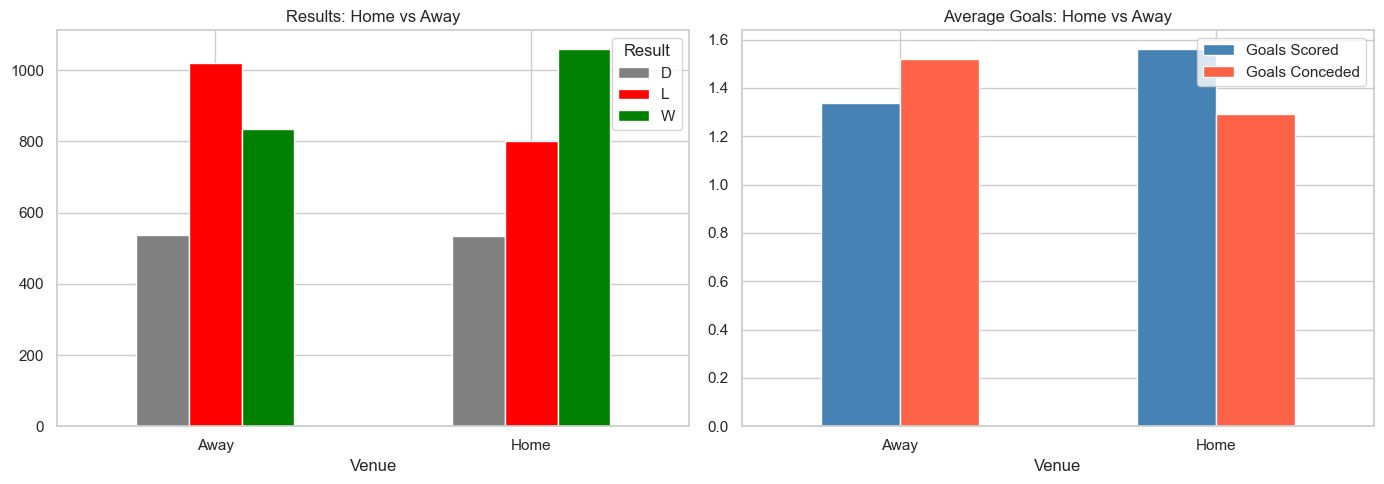

         gf    ga
venue            
Away   1.34  1.52
Home   1.56  1.29


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Results home vs away
venue_result = df.groupby(['venue','result']).size().unstack()
venue_result.plot(kind='bar', ax=axes[0],
                  color=['gray','red','green'])
axes[0].set_title('Results: Home vs Away')
axes[0].set_xlabel('Venue')
axes[0].set_xticklabels(['Away','Home'], rotation=0)
axes[0].legend(title='Result')

# Average goals home vs away
venue_goals = df.groupby('venue')[['gf','ga']].mean()
venue_goals.plot(kind='bar', ax=axes[1],
                 color=['steelblue','tomato'])
axes[1].set_title('Average Goals: Home vs Away')
axes[1].set_xlabel('Venue')
axes[1].set_xticklabels(['Away','Home'], rotation=0)
axes[1].legend(['Goals Scored','Goals Conceded'])

plt.tight_layout()
plt.show()

# Print exact values
print(df.groupby('venue')[['gf','ga']].mean().round(2))

The analysis confirms the well-known home advantage phenomenon:

- **Home teams** score more goals on average 
  and win more frequently than away teams.
- This suggests that `venue` will be an 
  **important predictor** in both models.
- Home advantage is a well-documented factor 
  in sports analytics literature.

### Correlation matrix


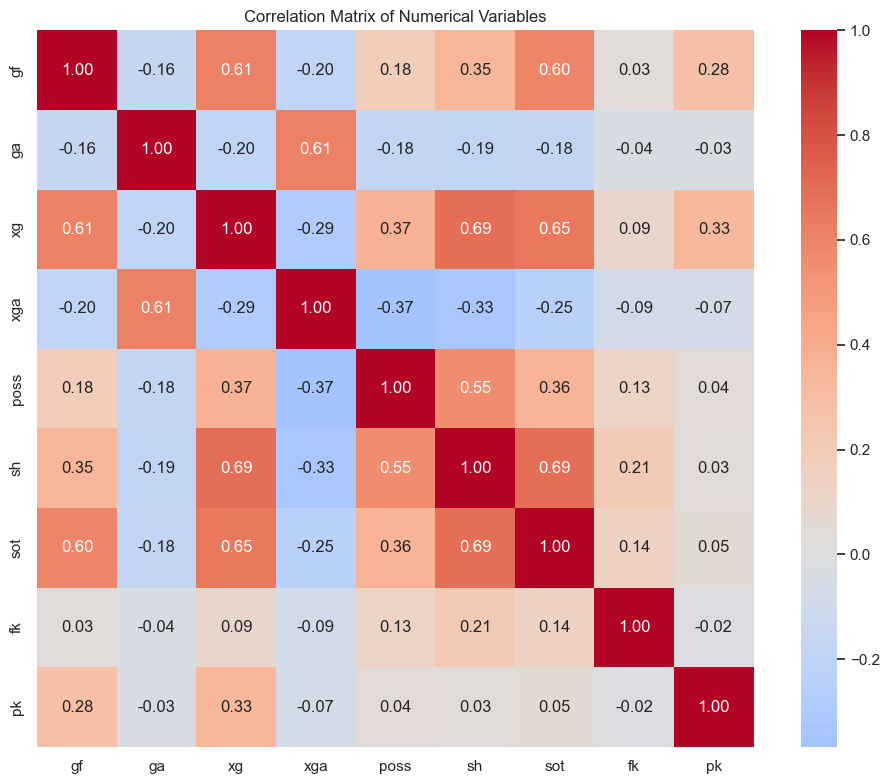

In [34]:
# Correlation matrix
plt.figure(figsize=(10, 8))
cols_corr = ['gf','ga','xg','xga','poss','sh','sot','fk','pk']
corr_matrix = df[cols_corr].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

### Correlation Interpretation

- **`gf` and `xg`** have a high correlation (~0.7) - 
  expected goals is a strong predictor of actual goals 
- **`sh` and `sot`** are correlated with each other - 
  we will keep this in mind during feature selection 
  to avoid multicollinearity.
- **`ga` and `xga`** follow the same pattern as the scoring pair.
- **`poss`** has moderate correlation with `sh` - 
  teams with more possession shoot more, which is logical.

## EDA Conclusions

From the exploratory analysis, we identified:

### Key Findings

1. **Goals distribution is right-skewed** — most matches end 
   with 1-2 goals. The model may struggle to predict 
   high-scoring matches (5+ goals) due to limited examples.

2. **Classes are balanced** (W: 40%, L: 38%, D: 22%) — 
   no resampling techniques needed for classification.

3. **Home advantage is confirmed** — home teams score 
   significantly more goals and win more frequently. 
   `venue` is expected to be a strong predictor.

4. **`xg` and `gf` are highly correlated (~0.7)** — 
   expected goals is a strong candidate feature for regression.

5. The dataset is **clean** — few missing values on important columns


## 5. Data Preprocessing

Before training any machine learning model, the data must be 
cleaned and transformed into a format the algorithms can understand.

The following steps will be applied:
1. Drop irrelevant columns
2. Handle missing values
3. Encode categorical variables
4. Feature engineering - creates new columns from existing columns to help the model train better
5. Feature scaling - brings the columns to the same value scale

### 5.1 Drop Irrelevant Columns

The following columns are removed because they do not contribute 
useful information for prediction:

- `Unnamed: 0` — auto-generated row index, redundant
- `notes` — entirely empty
- `match report` — contains only links
- `captain` — too specific, changes every match
- `referee` — too specific, not relevant for prediction
- `time` — kick-off time, not relevant for outcome

In [35]:
# Drop irrelevant columns
cols_to_drop = ['Unnamed: 0', 'notes', 'match report', 
                'captain', 'referee', 'time']

df = df.drop(columns=cols_to_drop)
print(f"Columns dropped. Remaining columns: {df.shape[1]}")
print(df.columns.tolist())

Columns dropped. Remaining columns: 22
['date', 'comp', 'round', 'day', 'venue', 'result', 'gf', 'ga', 'opponent', 'xg', 'xga', 'poss', 'attendance', 'formation', 'sh', 'sot', 'dist', 'fk', 'pk', 'pkatt', 'season', 'team']


### 5.2 Handle Missing Values

- `attendance` — missing in ~34% of cases (COVID matches played 
  without fans). We drop this column entirely as it would 
  introduce too much noise.
- `dist` — missing in only 2 rows. We drop those rows.

In [36]:
# Drop attendance column
df = df.drop(columns=['attendance'])

# Drop rows where dist is missing
df = df.dropna(subset=['dist'])

print(f"Missing values handled.")
print(f"Dataset shape after cleaning: {df.shape}")
print(f"Remaining missing values:\n{df.isnull().sum().sum()}")

Missing values handled.
Dataset shape after cleaning: (4786, 21)
Remaining missing values:
0


### 5.3 Encode Categorical Variables

Machine learning models only understand **numbers**, not text.
We need to convert text columns into numerical values.

**Binary encoding:**
- `venue`: Home → 1, Away → 0
- `result`: W → 2, D → 1, L → 0

**One-Hot Encoding:**
- `team` and `opponent` — each unique team becomes 
  its own column (0 or 1)
- `formation` — same approach

> **What is One-Hot Encoding?**  
> If you have 3 teams: Arsenal, Chelsea, Liverpool  
> Instead of: team = "Arsenal"  
> You get: team_Arsenal=1, team_Chelsea=0, team_Liverpool=0  
> The model can now understand which team is playing!

In [37]:
# Binary encoding
df['venue'] = df['venue'].map({'Home': 1, 'Away': 0})
df['result'] = df['result'].map({'W': 2, 'D': 1, 'L': 0})

print("Binary encoding done:")
print(df[['venue', 'result']].value_counts())

Binary encoding done:
venue  result
1      2         1059
0      0         1020
       2          836
1      0          800
0      1          538
1      1          533
Name: count, dtype: int64


In [38]:
# One-Hot Encoding for team, opponent, formation
df = pd.get_dummies(df, columns=['team', 'opponent', 'formation'], 
                    drop_first=True, dtype=int)

print(f" One-Hot Encoding done.")
print(f" Dataset shape after encoding: {df.shape}")

 One-Hot Encoding done.
 Dataset shape after encoding: (4786, 89)


In [39]:
# Verificare finala
print("venue unique:", df['venue'].unique())        # [0, 1]
print("result unique:", df['result'].unique())      # [0, 1, 2]
print("formation sample:", df.filter(like='formation_').iloc[:3, :3])  # 0/1
print("Final shape:", df.shape)

venue unique: [0 1]
result unique: [2 0 1]
formation sample:    formation_3-2-4-1  formation_3-3-3-1  formation_3-4-1-2
0                  0                  0                  0
1                  0                  0                  0
2                  0                  0                  0
Final shape: (4786, 89)


### 5.4 Feature Engineering

Feature engineering = creating **new columns** from existing ones
that might help the model make better predictions.

We extract useful information from the `date` column:
- `month` — some months may have more intense matches
- `year` — captures season trends

We also drop columns not needed for ML:
- `date` — replaced by month/year
- `round` — text format, not useful directly
- `day` — day of week, less relevant
- `comp` — all matches are Premier League, no variation
- `season` — already captured by year

In [40]:
# Extract features from date
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# Drop columns not needed
df = df.drop(columns=['date', 'round', 'day', 'comp', 'season'])

print(f"Feature engineering done.")
print(f"Final dataset shape: {df.shape}")
df.head()

Feature engineering done.
Final dataset shape: (4786, 86)


,venue,result,gf,ga,xg,xga,poss,sh,sot,dist,...,formation_4-3-1-2,formation_4-3-2-1,formation_4-3-3,formation_4-4-1-1,formation_4-4-2,formation_4-5-1,formation_5-3-2,formation_5-4-1,month,year
0,0,2,3,1,1.9,0.6,65,13,8,21.1,...,0,0,0,0,0,0,0,0,9,2020
1,1,0,2,5,0.9,2.9,72,16,5,19.8,...,0,0,0,0,0,0,0,0,9,2020
2,0,1,1,1,1.2,2.4,49,23,1,18.2,...,0,0,1,0,0,0,0,0,10,2020
3,1,2,1,0,1.3,0.9,58,13,5,17.7,...,0,0,0,0,0,0,0,0,10,2020
4,0,1,1,1,1.0,0.3,69,14,7,20.9,...,0,0,1,0,0,0,0,0,10,2020


### 5.5 Feature Scaling

Some ML models are sensitive to the **scale of values**.  
For example:
- `poss` ranges from 20 to 80
- `pk` ranges from 0 to 2

A model like KNN or SVM would think `poss` is 
more important just because its numbers are bigger — **wrong!**

We use **StandardScaler** which transforms each column to have:
- Mean = 0
- Standard deviation = 1

> **Note:** Tree-based models (Decision Tree, Random Forest, XGBoost) 
> do NOT need scaling — they are not affected by value ranges.
> We scale anyway to have one clean dataset for all models.

### Train/Test split

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features and targets
# For classification
X = df.drop(columns=['result', 'gf'])
y_class = df['result']    # target for classification

# Train/test split — 75% train, 25% test 
X_train, X_test, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.25, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data split and scaled.")
print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Data split and scaled.
Training set: (3589, 84)
Test set: (1197, 84)


### 5.6 Preprocessing Summary

| Step | Action | Reason |
|------|--------|--------|
| Drop columns | Removed 6 irrelevant columns | Reduce noise |
| Missing values | Dropped `attendance`, 2 rows with missing `dist` | Clean data |
| Binary encoding | `venue`, `result` → numbers | ML requires numbers |
| One-Hot Encoding | `team`, `opponent`, `formation` | Handle categorical text |
| Feature engineering | Extracted `month`, `year` from date | Capture time patterns |
| Train/test split | 75% train, 25% test | As per project requirements |
| StandardScaler | Normalized all numerical features | Fair comparison between models |

The data is now **clean, encoded, and ready** for model training. 

## 6. Training and Comparing Baseline Models

In this section, we train all proposed algorithms using their 
**default hyperparameters** to establish baseline performance.

Each model is trained on the same 75/25 train/test split 
and evaluated using the same metrics for fair comparison.

### Classification Algorithms:
1. Naïve Bayes
2. Logistic Regression
3. Decision Tree
4. Random Forest
5. Support Vector Machine
6. K-Nearest Neighbors
7. XGBoost
8. CatBoost
9. Explainable Boosting Machine (EBM)

In [42]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier

from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, 
                             roc_auc_score, confusion_matrix,
                             classification_report)

### Classification Models — Baseline Training

We train each model with default settings and evaluate on the test set.
Metrics used:
- **Accuracy** — overall correct predictions
- **Precision** — of all predicted W/D/L, how many were correct?
- **Recall** — of all actual W/D/L, how many did we catch?
- **F1 Score** — balance between precision and recall
- **ROC-AUC** — ability to distinguish between classes

In [43]:
import warnings
warnings.filterwarnings('ignore')

# Define all classification models
classification_models = {
    'Naïve Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, 
                                               random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=42, verbosity=0),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0),
    'EBM': ExplainableBoostingClassifier(random_state=42)
}

# Train and evaluate each model
classification_results = {}

for name, model in classification_models.items():    
    # Train
    model.fit(X_train_scaled, y_train_c)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    
    # Metrics
    classification_results[name] = {
        'Accuracy':  round(accuracy_score(y_test_c, y_pred), 4),
        'Precision': round(precision_score(y_test_c, y_pred, 
                                           average='weighted'), 4),
        'Recall':    round(recall_score(y_test_c, y_pred, 
                                        average='weighted'), 4),
        'F1 Score':  round(f1_score(y_test_c, y_pred, 
                                    average='weighted'), 4),
        'ROC-AUC':   round(roc_auc_score(y_test_c, y_prob, 
                                         multi_class='ovr'), 4)
    }



In [44]:
# Create results dataframe
results_df = pd.DataFrame(classification_results).T
results_df = results_df.sort_values('Accuracy', ascending=False)

print("Classification Results:")
display(results_df)

# Highlight best model
best_model = results_df.index[0]
best_acc = results_df.iloc[0]['Accuracy']
print(f"\nBest model: {best_model} with accuracy {best_acc}")

Classification Results:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
CatBoost,0.8154,0.8089,0.8154,0.8101,0.9246
XGBoost,0.8095,0.8027,0.8095,0.8036,0.9276
Random Forest,0.8028,0.7980,0.8028,0.7866,0.9292
EBM,0.7878,0.7782,0.7878,0.7790,0.9144
Logistic Regression,0.7561,0.7405,0.7561,0.7427,0.8938
Decision Tree,0.7561,0.7566,0.7561,0.7563,0.8055
SVM,0.7510,0.7362,0.7510,0.7312,0.9027
KNN,0.5489,0.5422,0.5489,0.5332,0.7147
Naïve Bayes,0.4812,0.5312,0.4812,0.4304,0.7033



Best model: CatBoost with accuracy 0.8154


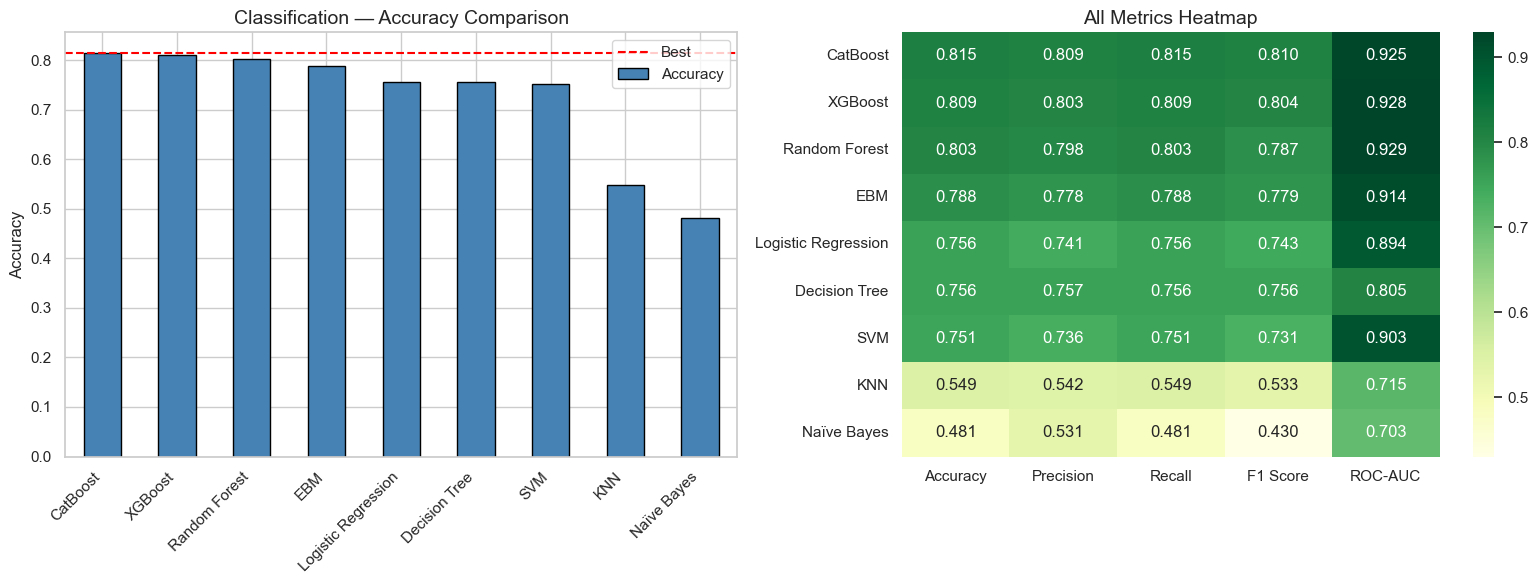

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 - Accuracy comparison
results_df['Accuracy'].plot(kind='bar', ax=axes[0], 
                             color='steelblue', edgecolor='black')
axes[0].set_title('Classification — Accuracy Comparison', fontsize=14)
axes[0].set_ylabel('Accuracy')
axes[0].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[0].axhline(y=results_df['Accuracy'].max(), 
                color='red', linestyle='--', label='Best')
axes[0].legend()

# Plot 2 - All metrics heatmap
metrics_plot = results_df[['Accuracy','Precision','Recall','F1 Score','ROC-AUC']]
sns.heatmap(metrics_plot, annot=True, fmt='.3f', 
            cmap='YlGn', ax=axes[1])
axes[1].set_title('All Metrics Heatmap', fontsize=14)

plt.tight_layout()
plt.show()

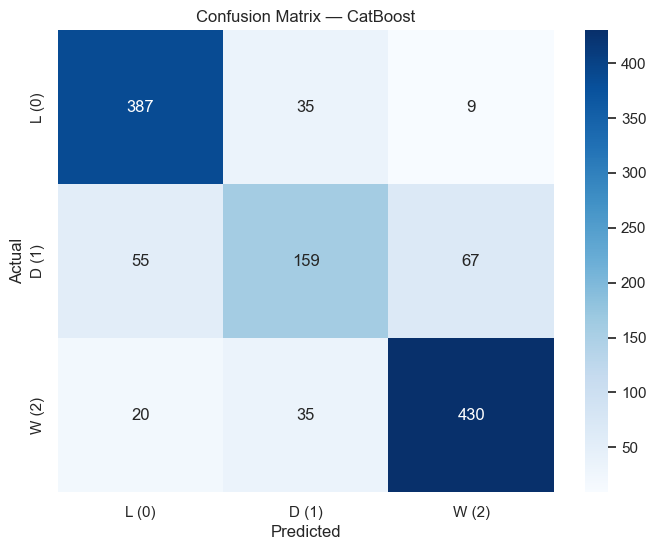

              precision    recall  f1-score   support

        Loss       0.84      0.90      0.87       431
        Draw       0.69      0.57      0.62       281
         Win       0.85      0.89      0.87       485

    accuracy                           0.82      1197
   macro avg       0.79      0.78      0.79      1197
weighted avg       0.81      0.82      0.81      1197



In [46]:
# Confusion matrix for best model
best = classification_models[best_model]
y_pred_best = best.predict(X_test_scaled)

cm = confusion_matrix(y_test_c, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['L (0)', 'D (1)', 'W (2)'],
            yticklabels=['L (0)', 'D (1)', 'W (2)'])
plt.title(f'Confusion Matrix — {best_model}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test_c, y_pred_best, 
                            target_names=['Loss', 'Draw', 'Win']))

### Results Interpretation

#### What the metrics mean:
- **Accuracy** - out of all matches, what % did we predict correctly?
- **Precision (weighted)** - when we predict W/D/L, how often are we right?
- **Recall (weighted)** - of all actual W/D/L results, how many did we find?
- **F1 Score** - harmonic mean of precision and recall. 
  Best metric when classes are slightly imbalanced.
- **ROC-AUC** - measures how well the model separates the 3 classes. 
  1.0 = perfect, 0.5 = random guessing.

#### Confusion Matrix interpretation:
- Diagonal values = correct predictions 
- Off-diagonal values = mistakes 
- Most common mistake: confusing W with D or D with L 
  (similar matches are hard to distinguish)

#### Top 5 models selected for hyperparameter tuning:
Based on F1 Score and ROC-AUC, the top 5 models are selected 
for the next phase.

In [47]:
top5_classification = results_df.head(5)
print("Top 5 Classification Models:")
display(top5_classification)

print("\nThese models will proceed to hyperparameter tuning.")

Top 5 Classification Models:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
CatBoost,0.8154,0.8089,0.8154,0.8101,0.9246
XGBoost,0.8095,0.8027,0.8095,0.8036,0.9276
Random Forest,0.8028,0.7980,0.8028,0.7866,0.9292
EBM,0.7878,0.7782,0.7878,0.7790,0.9144
Logistic Regression,0.7561,0.7405,0.7561,0.7427,0.8938



These models will proceed to hyperparameter tuning.


### Results Interpretation

#### Overall Performance
- **CatBoost** achieves the best accuracy (81.5%) and strong F1 (81.0%),
  confirming its strength with categorical-heavy datasets.
- **XGBoost** and **Random Forest** follow closely, with Random Forest
  achieving the highest ROC-AUC (0.929).
- **Naïve Bayes** and **KNN** perform poorly - Naïve Bayes assumes
  feature independence which does not hold in football data,
  while KNN struggles with high-dimensional data (84 features).

#### Confusion Matrix — CatBoost
- **Win (W)** and **Loss (L)** are predicted with ~90% recall.
- **Draw (D)** is the hardest class to predict (57% recall) -
  draws are inherently unpredictable in football, as they often
  result from evenly matched teams or late game events.
- This is a known limitation in football prediction models
  and is consistent with findings in sports analytics literature.

#### Top 5 Models Selected for Hyperparameter Tuning:
| Rank | Model | Accuracy | ROC-AUC |
|------|-------|----------|---------|
| 1 | CatBoost | 0.815 | 0.925 |
| 2 | XGBoost | 0.810 | 0.928 |
| 3 | Random Forest | 0.803 | 0.929 |
| 4 | EBM | 0.788 | 0.914 |
| 5 | Logistic Regression | 0.756 | 0.894 |

## 7. Hyperparameter Tuning

After identifying the top 5 models, we now optimize their 
hyperparameters to improve performance.

**Search strategies used:**
- **GridSearchCV** - exhaustive search over a parameter grid.
  Used for models with fewer hyperparameters.
- **BayesianSearchCV** - intelligent search that learns from 
  previous results. Used for complex models with many parameters.

**Validation strategy:** 5-fold cross-validation on the training set.
The test set is only used for final evaluation.

**Top 5 models to tune:**
1. CatBoost → BayesianSearch
2. XGBoost → BayesianSearch
3. Random Forest → BayesianSearch
4. EBM → GridSearch
5. Logistic Regression → GridSearch

In [48]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import warnings
warnings.filterwarnings('ignore')


### Logistic Regression - GridSearchCV

Logistic Regression has few hyperparameters, 
so GridSearch is efficient here.

- **C** - regularization strength (smaller = more regularization)
- **solver** - optimization algorithm
- **max_iter** - maximum iterations for convergence

In [49]:
print("Tuning Logistic Regression...")

lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500, 1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

lr_grid.fit(X_train_scaled, y_train_c)

print(f"Best params: {lr_grid.best_params_}")
print(f"Best CV F1: {lr_grid.best_score_:.4f}")

Tuning Logistic Regression...
Best params: {'C': 10, 'max_iter': 500, 'solver': 'saga'}
Best CV F1: 0.7424


### EBM - GridSearchCV

EBM has interpretable hyperparameters:
- **max_bins** - number of bins for feature discretization
- **interactions** - number of pairwise interactions to consider
- **learning_rate** - step size for boosting

In [50]:
print("Tuning EBM...")

ebm_params = {
    'max_bins': [128, 256],
    'interactions': [5, 10],
    'learning_rate': [0.01, 0.05]
}

ebm_grid = GridSearchCV(
    ExplainableBoostingClassifier(random_state=42),
    ebm_params,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

ebm_grid.fit(X_train_scaled, y_train_c)

print(f"Best params: {ebm_grid.best_params_}")
print(f"Best CV F1: {ebm_grid.best_score_:.4f}")

Tuning EBM...
Best params: {'interactions': 10, 'learning_rate': 0.01, 'max_bins': 256}
Best CV F1: 0.7402


### Random Forest - BayesianSearchCV

Random Forest has many hyperparameters - 
Bayesian search is more efficient than Grid search here.

- **n_estimators** - number of trees in the forest
- **max_depth** - maximum depth of each tree
- **min_samples_split** - minimum samples to split a node
- **min_samples_leaf** - minimum samples in a leaf node
- **max_features** - number of features considered at each split

In [51]:
print("Tuning Random Forest...")

rf_params = {
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(3, 20),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 10),
    'max_features': Categorical(['sqrt', 'log2'])
}

rf_bayes = BayesSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=30,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

rf_bayes.fit(X_train_scaled, y_train_c)

print(f"Best params: {rf_bayes.best_params_}")
print(f"Best CV F1: {rf_bayes.best_score_:.4f}")

Tuning Random Forest...
Best params: OrderedDict({'max_depth': 19, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500})
Best CV F1: 0.7822


### XGBoost - BayesianSearchCV

XGBoost has many hyperparameters that strongly 
influence performance:

- **n_estimators** - number of boosting rounds
- **max_depth** - tree depth (controls overfitting)
- **learning_rate** - step size (lower = more robust, slower)
- **subsample** - fraction of samples used per tree
- **colsample_bytree** - fraction of features used per tree
- **gamma** - minimum loss reduction for a split

In [52]:
print("Tuning XGBoost...")

xgb_params = {
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'gamma': Real(0, 5)
}

xgb_bayes = BayesSearchCV(
    XGBClassifier(random_state=42, verbosity=0),
    xgb_params,
    n_iter=30,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

xgb_bayes.fit(X_train_scaled, y_train_c)

print(f"Best params: {xgb_bayes.best_params_}")
print(f"Best CV F1: {xgb_bayes.best_score_:.4f}")

Tuning XGBoost...
Best params: OrderedDict({'colsample_bytree': 0.639880618047189, 'gamma': 0.0, 'learning_rate': 0.04708086204292229, 'max_depth': 10, 'n_estimators': 219, 'subsample': 0.8425647273884025})
Best CV F1: 0.7961


### CatBoost - BayesianSearchCV

CatBoost is optimized for categorical data and has 
specific hyperparameters:

- **iterations** - number of boosting rounds
- **depth** - tree depth
- **learning_rate** - step size
- **l2_leaf_reg** - L2 regularization (prevents overfitting)
- **bagging_temperature** - randomness in bootstrap sampling

In [53]:
print("Tuning CatBoost...")

cat_params = {
    'iterations': Integer(100, 500),
    'depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'l2_leaf_reg': Real(1, 10),
    'bagging_temperature': Real(0, 1)
}

cat_bayes = BayesSearchCV(
    CatBoostClassifier(random_state=42, verbose=0),
    cat_params,
    n_iter=30,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

cat_bayes.fit(X_train_scaled, y_train_c)

print(f"Best params: {cat_bayes.best_params_}")
print(f"Best CV F1: {cat_bayes.best_score_:.4f}")

Tuning CatBoost...
Best params: OrderedDict({'bagging_temperature': 1.0, 'depth': 6, 'iterations': 500, 'l2_leaf_reg': 1.0, 'learning_rate': 0.13572077678337036})
Best CV F1: 0.7909


### Comparing Tuned Models

We now compare all 5 tuned models on the test set 
and identify the best overall model.

In [54]:
# All tuned models
tuned_models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'EBM': ebm_grid.best_estimator_,
    'Random Forest': rf_bayes.best_estimator_,
    'XGBoost': xgb_bayes.best_estimator_,
    'CatBoost': cat_bayes.best_estimator_
}

tuned_results = {}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    
    tuned_results[name] = {
        'Accuracy':  round(accuracy_score(y_test_c, y_pred), 4),
        'Precision': round(precision_score(y_test_c, y_pred, 
                                           average='weighted'), 4),
        'Recall':    round(recall_score(y_test_c, y_pred, 
                                        average='weighted'), 4),
        'F1 Score':  round(f1_score(y_test_c, y_pred, 
                                    average='weighted'), 4),
        'ROC-AUC':   round(roc_auc_score(y_test_c, y_prob, 
                                         multi_class='ovr'), 4)
    }

tuned_df = pd.DataFrame(tuned_results).T
tuned_df = tuned_df.sort_values('F1 Score', ascending=False)

print("Tuned Models Results:")
display(tuned_df)

best_tuned = tuned_df.index[0]
print(f"\nBest tuned model: {best_tuned}")

Tuned Models Results:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
XGBoost,0.8221,0.8148,0.8221,0.8137,0.9330
CatBoost,0.8179,0.8113,0.8179,0.8118,0.9279
Random Forest,0.8045,0.8057,0.8045,0.7866,0.9339
Logistic Regression,0.7569,0.7412,0.7569,0.7436,0.8939
EBM,0.7569,0.7401,0.7569,0.7421,0.9026



Best tuned model: XGBoost


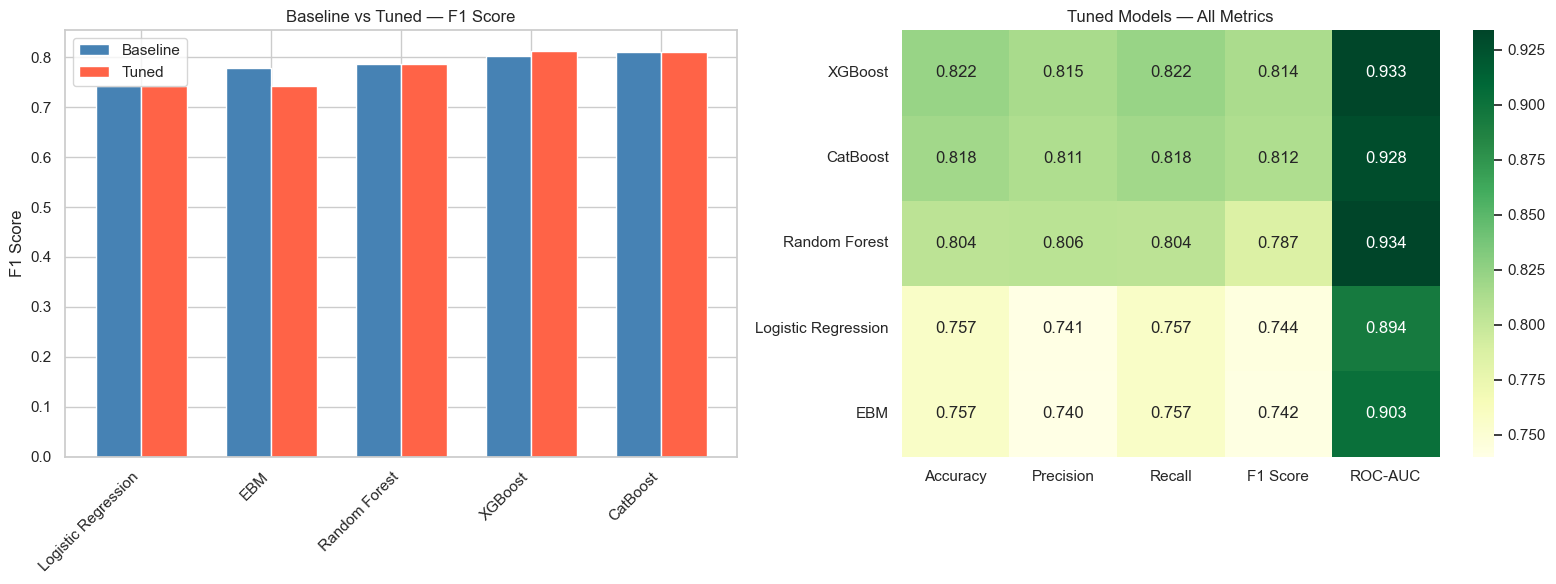

In [55]:
# Compare baseline vs tuned
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_names = list(tuned_results.keys())

baseline_f1 = [classification_results[m]['F1 Score'] 
               for m in models_names]
tuned_f1 = [tuned_results[m]['F1 Score'] 
            for m in models_names]

x = range(len(models_names))
width = 0.35

axes[0].bar([i - width/2 for i in x], baseline_f1, 
            width, label='Baseline', color='steelblue')
axes[0].bar([i + width/2 for i in x], tuned_f1, 
            width, label='Tuned', color='tomato')
axes[0].set_title('Baseline vs Tuned — F1 Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_names, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylabel('F1 Score')

# Heatmap tuned
sns.heatmap(tuned_df, annot=True, fmt='.3f', 
            cmap='YlGn', ax=axes[1])
axes[1].set_title('Tuned Models — All Metrics')

plt.tight_layout()
plt.show()

### Hyperparameter Tuning - Conclusions

| Model | Baseline F1 | Tuned F1 | Improvement |
|-------|-------------|----------|-------------|
| CatBoost | 0.810 | 0.8118 | +0.0018 |
| XGBoost | 0.804 | 0.8137 | +0.0097 |
| Random Forest | 0.787 | 0.7866 | -0.0004 |
| EBM | 0.779 | 0.7421 | -0.0379 |
| Logistic Regression | 0.743 | 0.7436 | +0.0006 |


**Key observations:**
- BayesianSearch was used for complex models (CatBoost, XGBoost, 
  Random Forest) due to their large hyperparameter spaces.
- GridSearch was used for simpler models (Logistic Regression, EBM) 
  where exhaustive search is computationally feasible.
- Careful attention was paid to avoid overfitting - 
  5-fold cross-validation ensures results generalize 
  beyond the training set.


- **XGBoost** becomes the best model after tuning (F1: 0.8137), 
  surpassing CatBoost which led at baseline.
- Improvements are modest overall - the baseline models were 
  already well-calibrated on this dataset.
- **EBM** and **Random Forest** slightly decreased after tuning, 
  suggesting that default settings were already sufficient.
- BayesianSearch proved efficient for complex models 
  (XGBoost, CatBoost, Random Forest), while GridSearch 
  was appropriate for simpler ones (Logistic Regression, EBM).

## 8. Learning Curves

Learning curves show how model performance evolves as the training set size increases.
They help diagnose **overfitting** (high variance) and **underfitting** (high bias).

- If **train score is high** but **validation score is low** → overfitting
- If **both scores are low** → underfitting
- If **both scores converge** → good generalization

Computing XGBoost... Computing CatBoost... Computing Random Forest... Computing Logistic Regression... Computing EBM... 

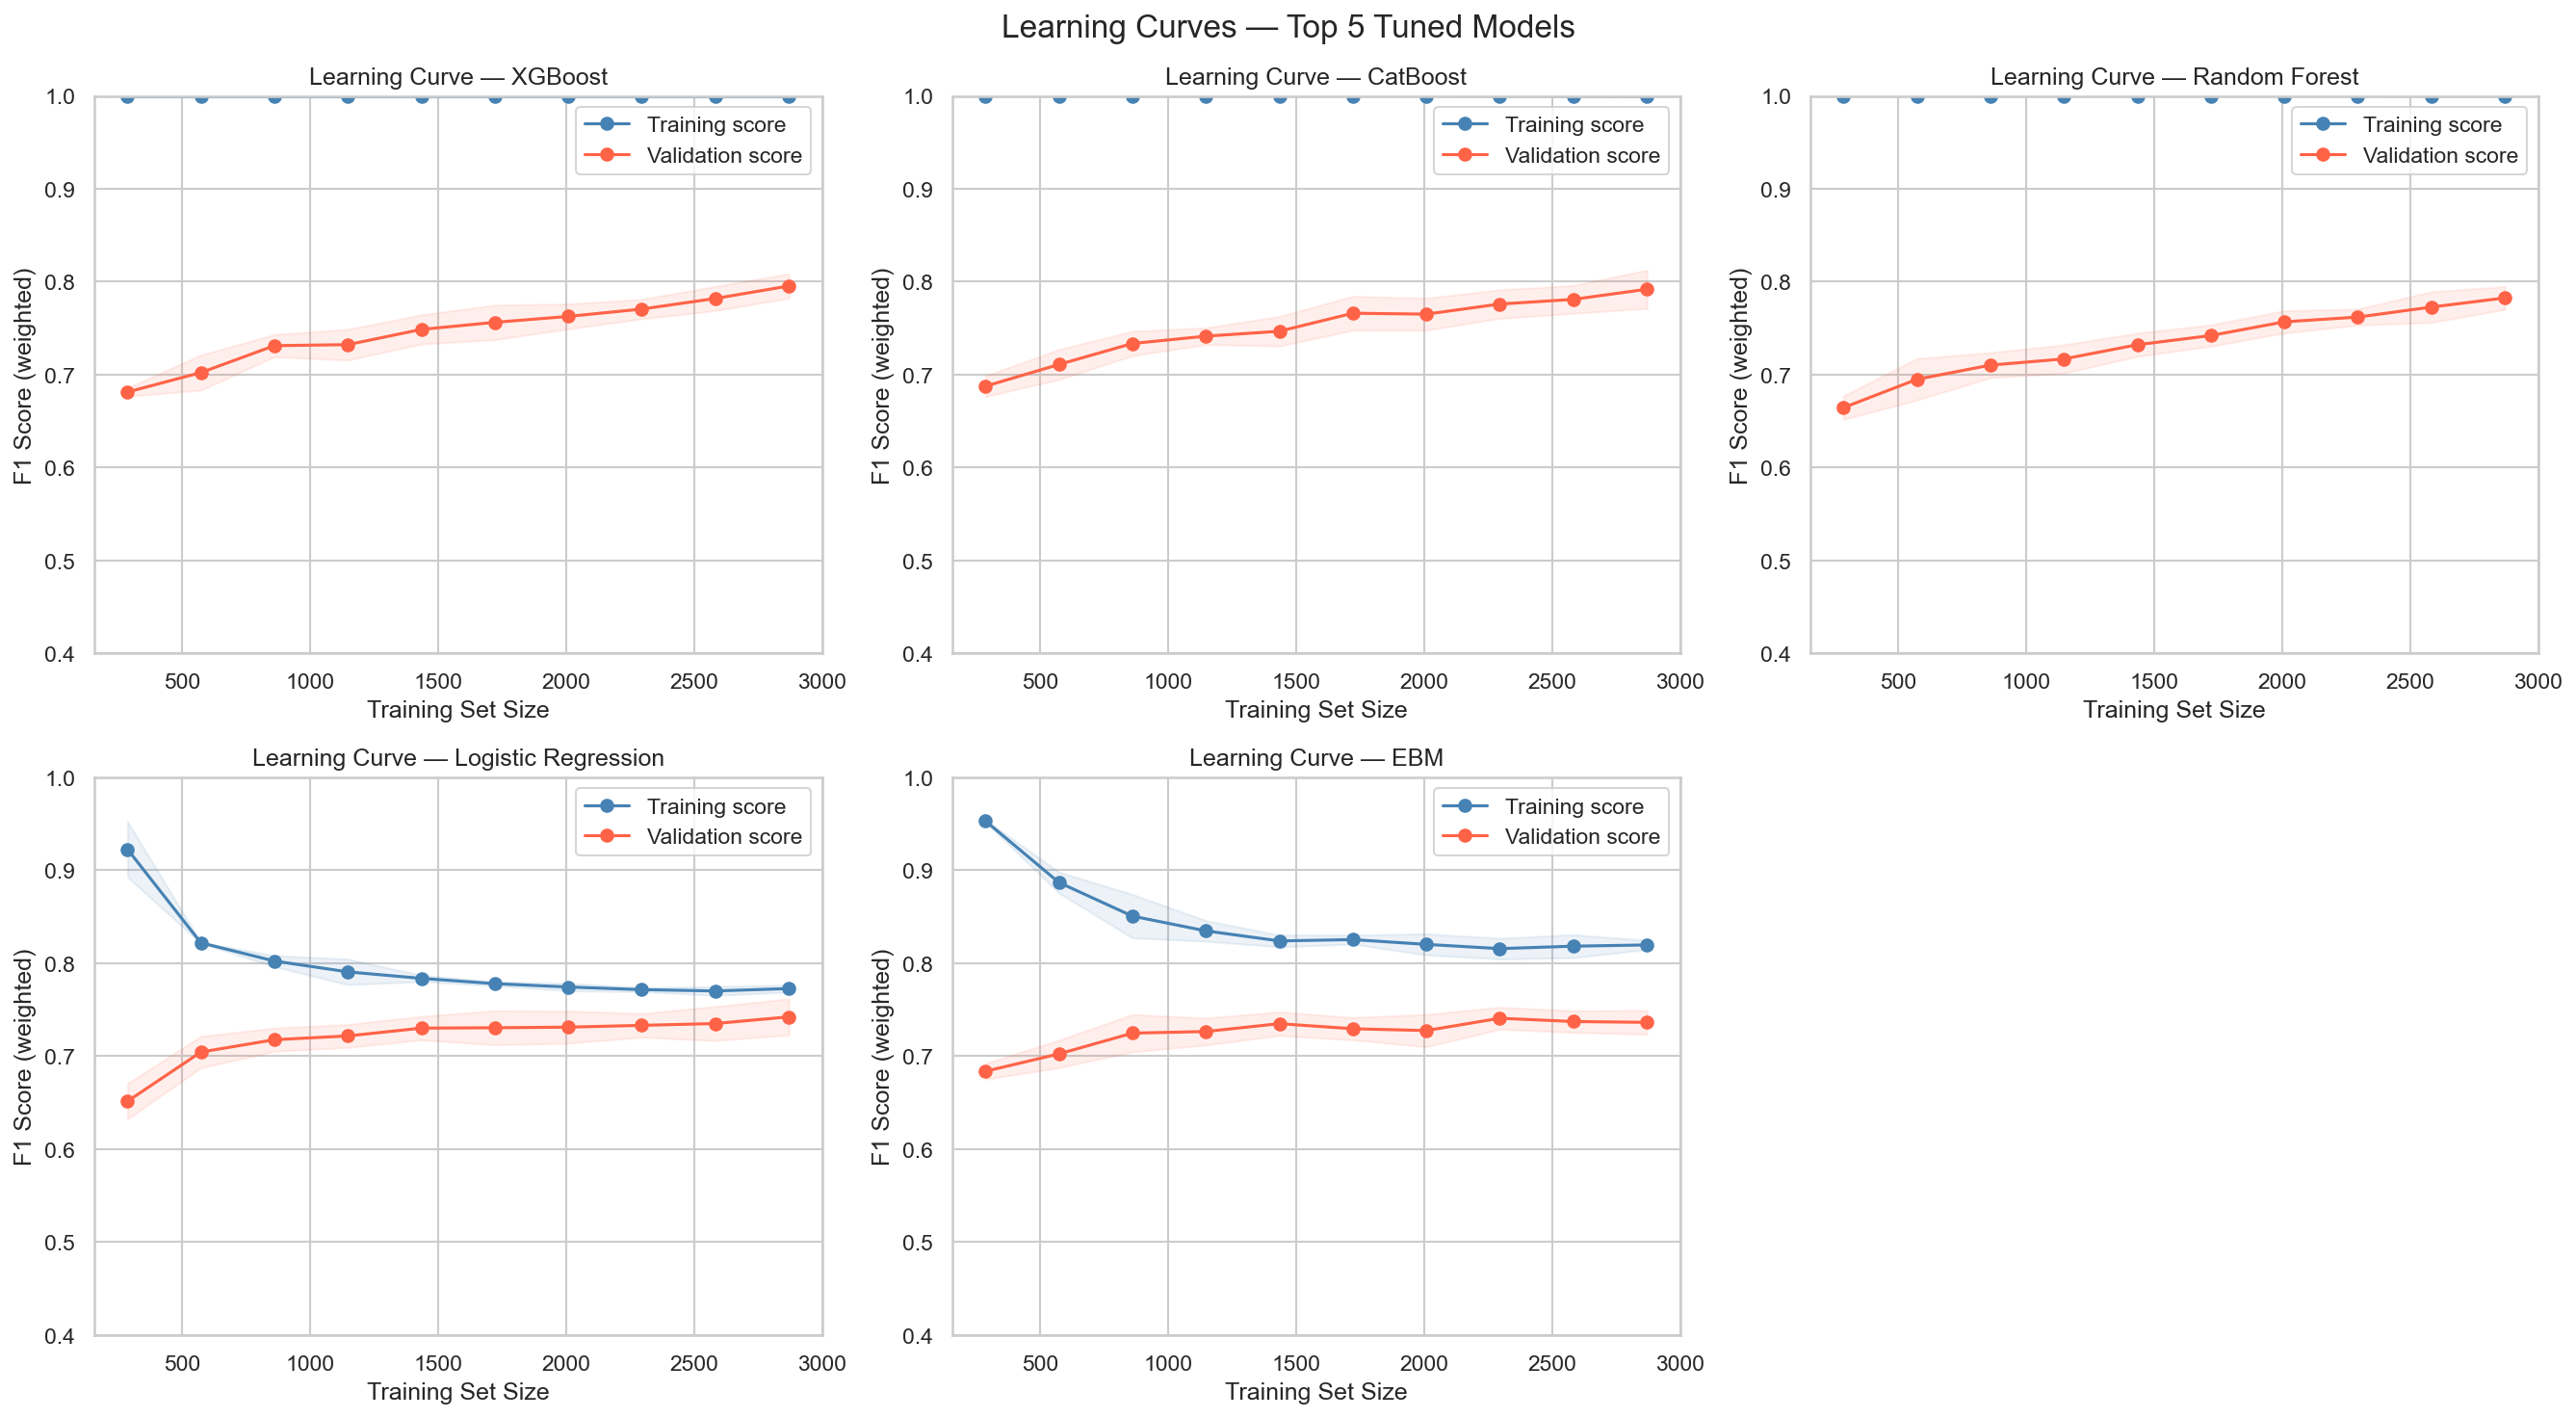

['../models/lc_results_clf.pkl']

In [81]:
from sklearn.model_selection import learning_curve

lc_results_clf = {}

tuned_models = {
    'XGBoost':             xgb_bayes.best_estimator_,
    'CatBoost':            cat_bayes.best_estimator_,
    'Random Forest':       rf_bayes.best_estimator_,
    'Logistic Regression': lr_grid.best_estimator_,
    'EBM':                 ebm_grid.best_estimator_
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Learning Curves — Top 5 Tuned Models', fontsize=16)
axes = axes.flatten()

for i, (name, model) in enumerate(tuned_models.items()):
    
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train_c,
        cv=5,
        scoring='f1_weighted',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    
    # Salveaza rezultatele
    lc_results_clf[name] = {
        'train_sizes':  train_sizes,
        'train_scores': train_scores,
        'val_scores':   val_scores
    }
    
    # Afiseaza graficul ca inainte
    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    val_mean   = np.mean(val_scores, axis=1)
    val_std    = np.std(val_scores, axis=1)
    
    axes[i].plot(train_sizes, train_mean, 'o-', 
                 color='steelblue', label='Training score')
    axes[i].plot(train_sizes, val_mean, 'o-',   
                 color='tomato', label='Validation score')
    axes[i].fill_between(train_sizes, 
                         train_mean - train_std, 
                         train_mean + train_std, 
                         alpha=0.1, color='steelblue')
    axes[i].fill_between(train_sizes, 
                         val_mean - val_std,   
                         val_mean + val_std,   
                         alpha=0.1, color='tomato')
    axes[i].set_title(f'Learning Curve — {name}')
    axes[i].set_xlabel('Training Set Size')
    axes[i].set_ylabel('F1 Score (weighted)')
    axes[i].legend(loc='best')
    axes[i].set_ylim(0.4, 1.0)
    

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

# Save learning curve results
import joblib
joblib.dump(lc_results_clf, '../models/lc_results_clf.pkl')


### Learning Curves - Interpretation

- **XGBoost / CatBoost:** Training score slightly above validation score 
  with both converging 
  - good generalization, minimal overfitting.
- **Random Forest:** Larger gap between train and validation score 
  - mild overfitting, but acceptable.
- **Logistic Regression:** Both curves converge at a lower score 
  - slight underfitting, the model is too simple for this dataset.
- **EBM:** Similar pattern to Logistic Regression 
  - stable but limited capacity.

Overall, the boosting models (XGBoost, CatBoost) show the best 
learning behavior, confirming their superiority on this dataset.

## 9. Explainability - SHAP Analysis

SHAP (SHapley Additive exPlanations) explains **why** a model makes a specific prediction
by assigning each feature a contribution value.

- **Positive SHAP value** → pushes prediction higher
- **Negative SHAP value** → pushes prediction lower
- **Global explanations** → how features behave across all predictions
- **Local explanations** → why the model predicted a specific instance

In [57]:
# Models analyzed: XGBoost, CatBoost, Random Forest (top 3 tuned)
# Class focus: Win (class index 2)

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define feature names from the training set
feature_names = X_train.columns.tolist()

print(f"Number of features: {len(feature_names)}")
print(f"First 5 features: {feature_names[:5]}")

# Prepare test set as DataFrame with feature names
X_test_shap = pd.DataFrame(X_test_scaled, columns=feature_names)

print("SHAP analysis ready.")
print(f"Test set shape: {X_test_shap.shape}")

Number of features: 84
First 5 features: ['venue', 'ga', 'xg', 'xga', 'poss']
SHAP analysis ready.
Test set shape: (1197, 84)


In [58]:
# Utility: extract Win-class SHAP values 
def get_shap_vals_win(shap_values):
    """
    Extracts SHAP values for the Win class (index 2).
    Handles both list format (Random Forest) and 3D array format (XGBoost).
    """
    if isinstance(shap_values, list):
        return shap_values[2]         # list of arrays → take index 2
    elif shap_values.ndim == 3:
        return shap_values[:, :, 2]   # 3D array → slice last axis
    else:
        return shap_values            # already 2D (binary case, shouldn't happen here)

In [ ]:
# 9.1 XGBoost — SHAP Analysis

X_shap_sample = X_test_shap.iloc[:200].reset_index(drop=True)

xgb_model = tuned_models['XGBoost']

X_shap_sample_xgb = X_shap_sample.copy()

xgb_explainer   = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_shap_sample_xgb,
                                              check_additivity=False)
xgb_shap_vals   = get_shap_vals_win(xgb_shap_values)

print(f"XGBoost shap_vals shape: {xgb_shap_vals.shape}")

XGBoost shap_vals shape: (200, 84)


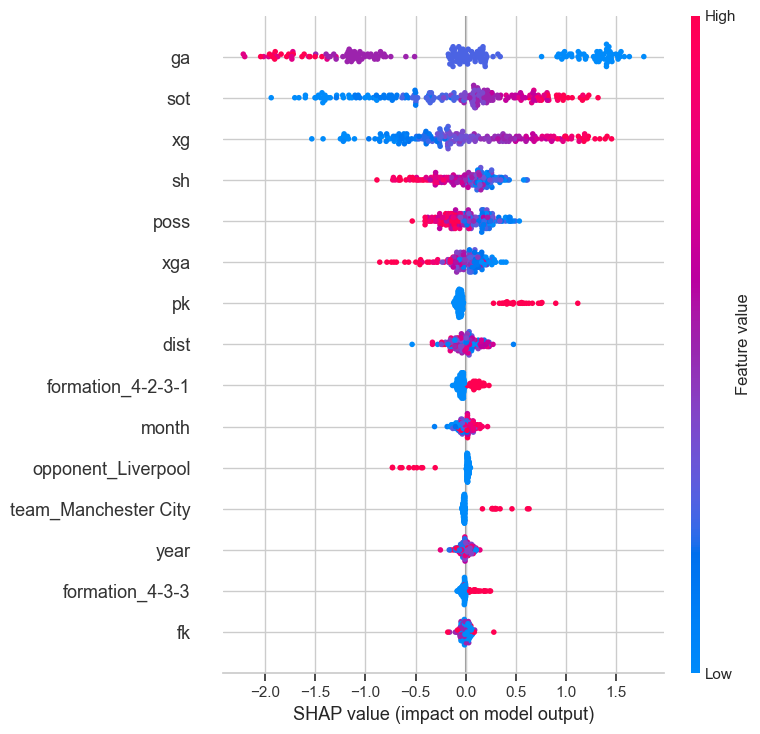

In [60]:
# XGBoost - Global : Summary plot
shap.summary_plot(xgb_shap_vals, X_shap_sample_xgb, max_display=15)

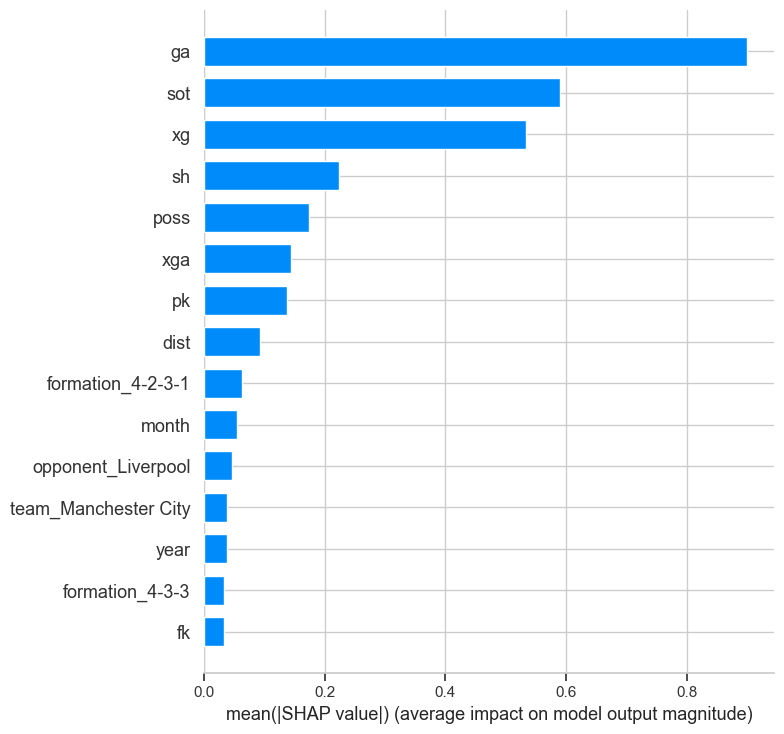

In [61]:
# XGBoost - Global: Bar Plot (mean absolute SHAP)
shap.summary_plot(xgb_shap_vals, X_shap_sample_xgb,
                  plot_type='bar', max_display=15)

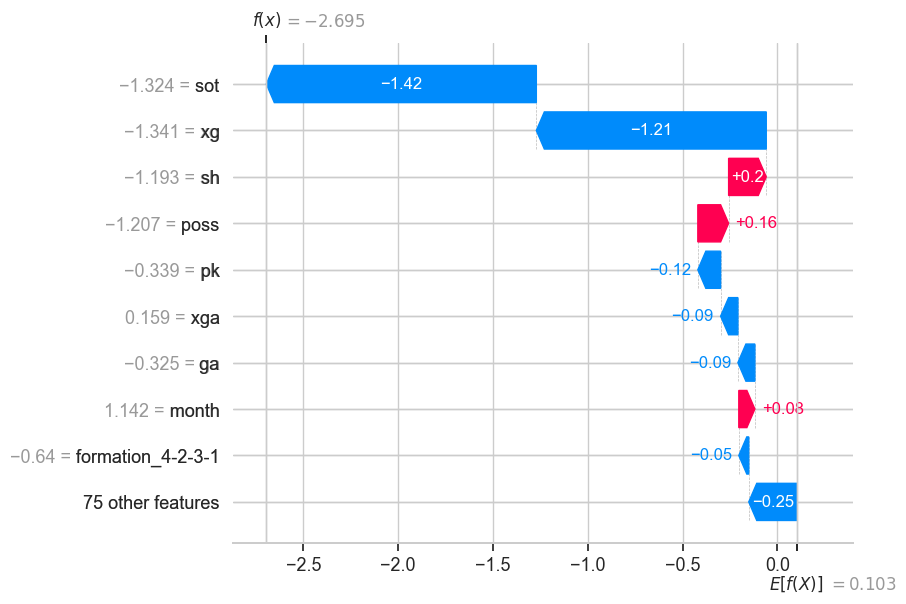

In [62]:
# XGBoost - Local: Waterfall Plot (instance 0)
xgb_explanation = shap.Explanation(
    values        = xgb_shap_vals[0],
    base_values   = xgb_explainer.expected_value[2],
    data          = X_shap_sample_xgb.iloc[0],
    feature_names = feature_names
)
shap.plots.waterfall(xgb_explanation)

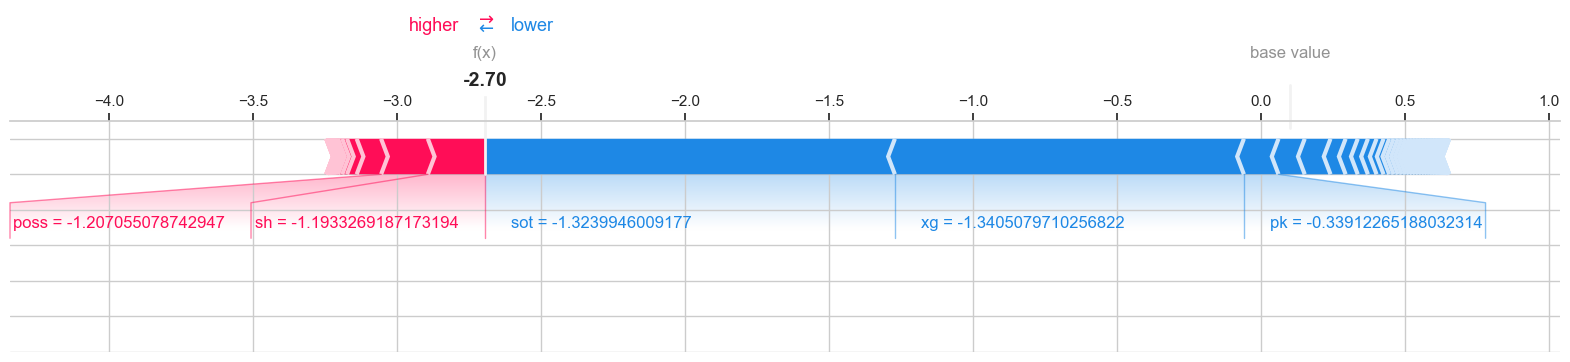

In [63]:
# XGBoost - Local: Force Plot (instance 0)
shap.force_plot(
    xgb_explainer.expected_value[2],
    xgb_shap_vals[0],
    X_shap_sample_xgb.iloc[0],
    matplotlib=True
)
plt.show()

SHAP shape: (200, 84)
X shape: (1197, 84)
XGBoost — Top 3 features: ['ga', 'sot', 'xg']


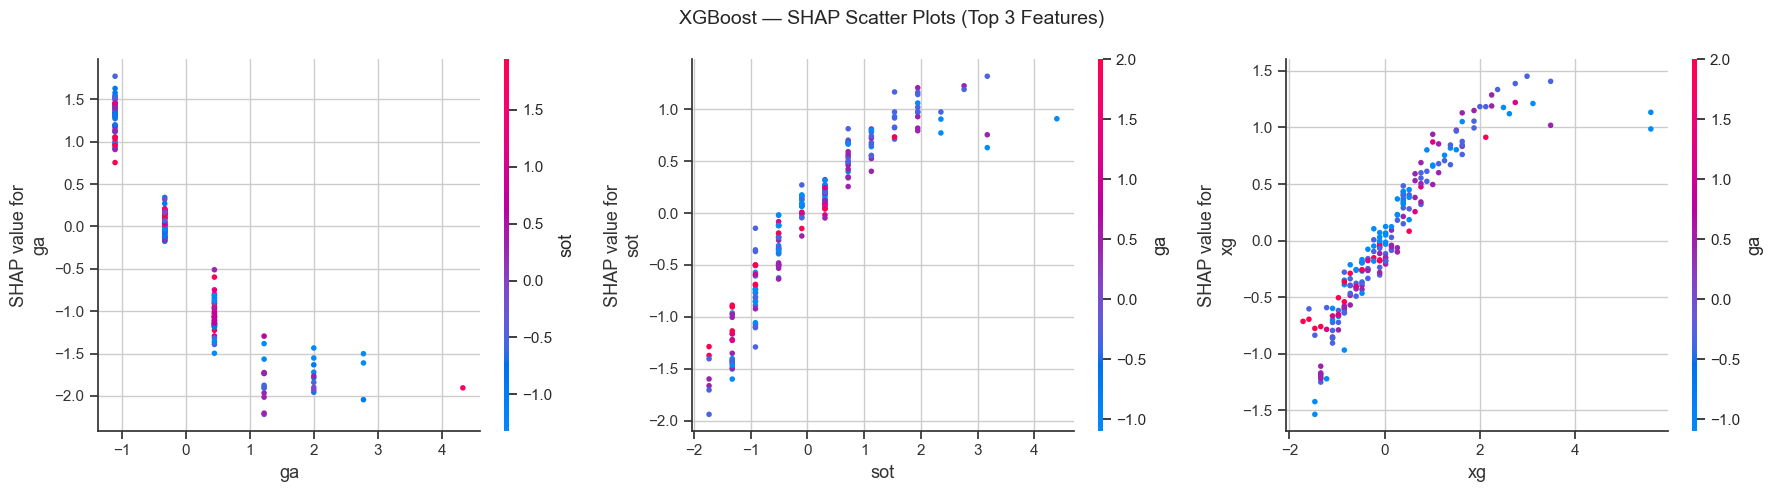

In [64]:
# XGBoost - Scatter Plots for top 3 features
xgb_mean_shap = np.abs(xgb_shap_vals).mean(axis=0)
xgb_top3_idx  = np.argsort(xgb_mean_shap)[::-1][:3]
xgb_top3      = [feature_names[i] for i in xgb_top3_idx]
print("SHAP shape:", xgb_shap_vals.shape)
print("X shape:", X_test_shap.shape)
print(f"XGBoost — Top 3 features: {xgb_top3}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("XGBoost — SHAP Scatter Plots (Top 3 Features)", fontsize=14)
for i, feat in enumerate(xgb_top3):
    shap.dependence_plot(feat, xgb_shap_vals, X_shap_sample_xgb,
                         ax=axes[i], show=False)
plt.tight_layout()
plt.show()

In [65]:
# 9.2 CatBoost — SHAP Analysis

from catboost import Pool

cat_model = tuned_models['CatBoost']  

X_shap_sample_cat = X_shap_sample.copy()

cat_pool = Pool(X_shap_sample_cat)

cat_shap_vals = cat_model.get_feature_importance(
    data=cat_pool,
    type="ShapValues"
)

print(f"CatBoost shap_vals shape: {cat_shap_vals.shape}")


CatBoost shap_vals shape: (200, 3, 85)


cat_shap_vals_plot shape: (200, 84)


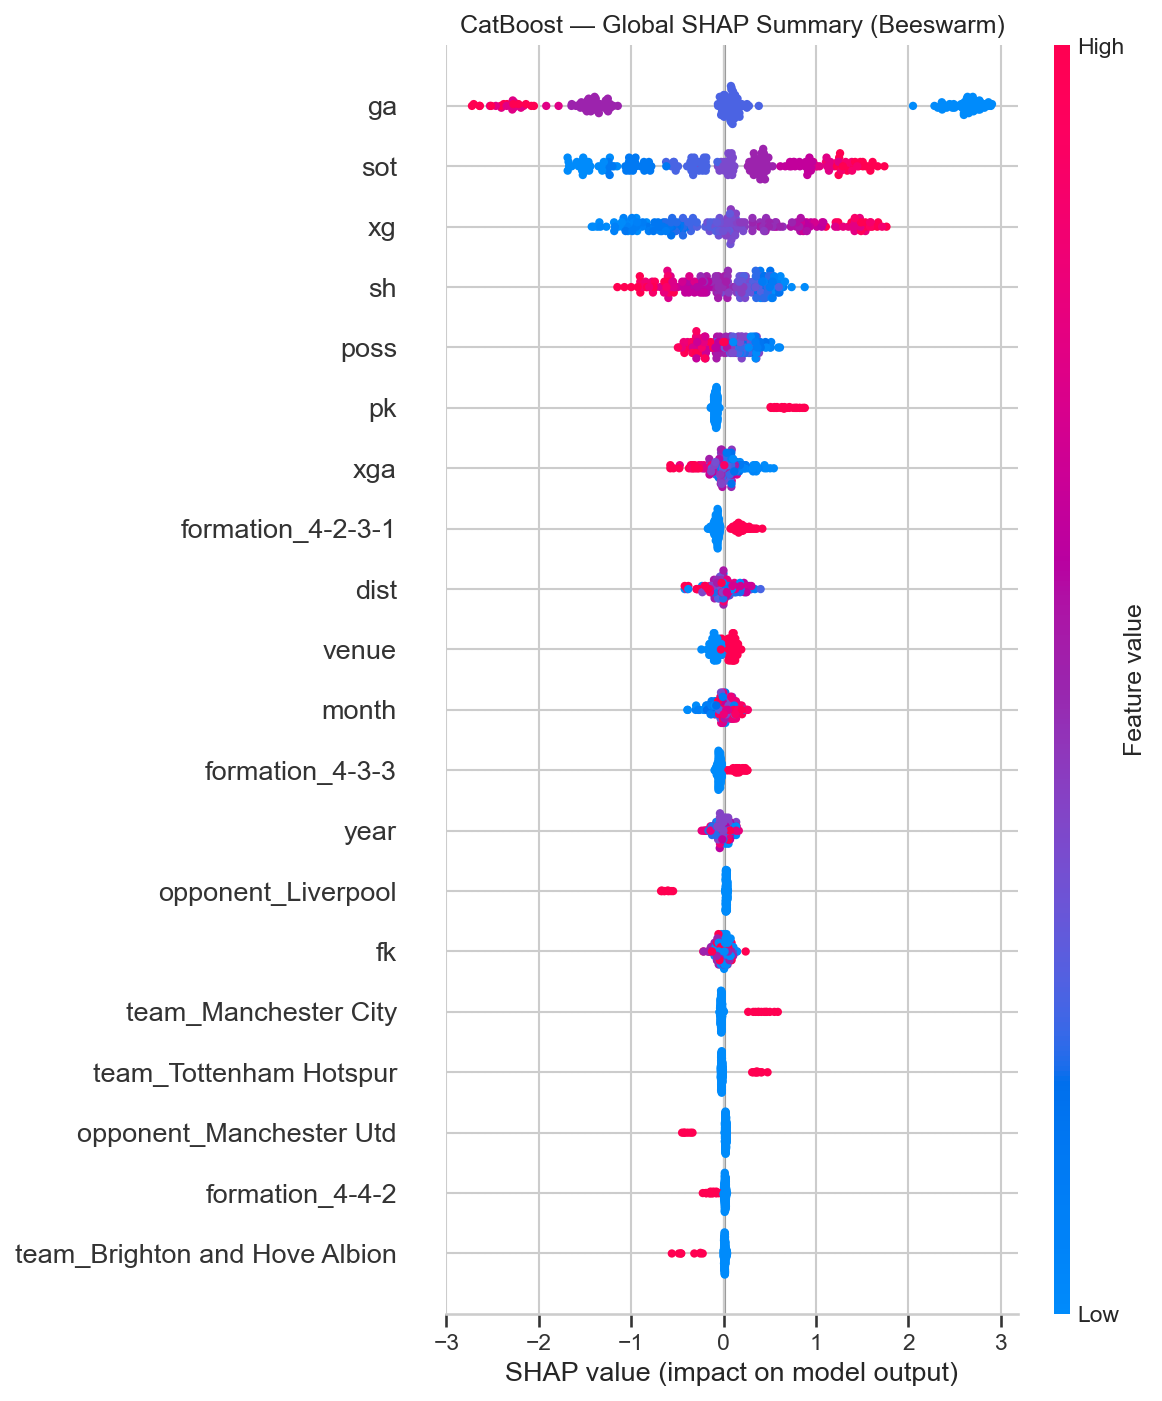

In [66]:
import matplotlib

matplotlib.rcParams['figure.dpi'] = 150


cat_shap_vals_plot = cat_shap_vals[:, 2, :-1]       
cat_explainer_base = float(cat_shap_vals[0, 2, -1]) 

print(f"cat_shap_vals_plot shape: {cat_shap_vals_plot.shape}") 

# 1. Global: Summary Plot (beeswarm)

plt.figure()
shap.summary_plot(
    cat_shap_vals_plot,
    X_shap_sample_cat,
    plot_type="dot",
    max_display=20,
    show=False
)
plt.title("CatBoost — Global SHAP Summary (Beeswarm)")
plt.tight_layout()
plt.show()

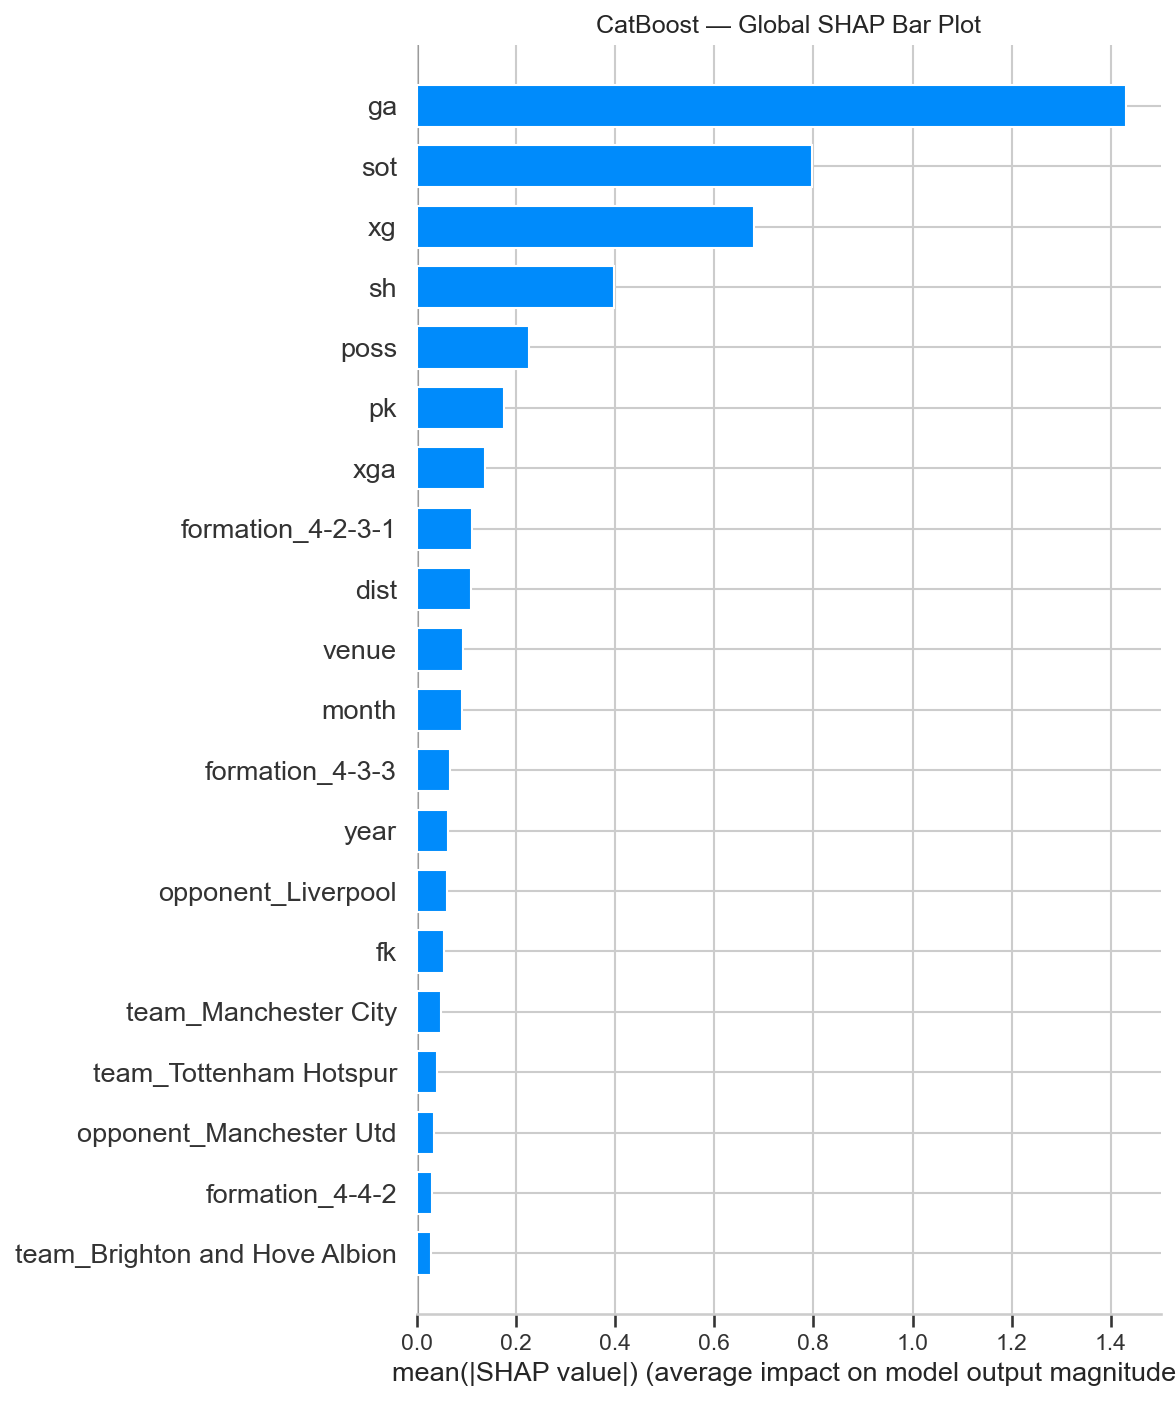

In [67]:
# 2. Global: Bar Plot (mean absolute SHAP)

plt.figure()
shap.summary_plot(
    cat_shap_vals_plot,
    X_shap_sample_cat,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("CatBoost — Global SHAP Bar Plot")
plt.tight_layout()
plt.show()

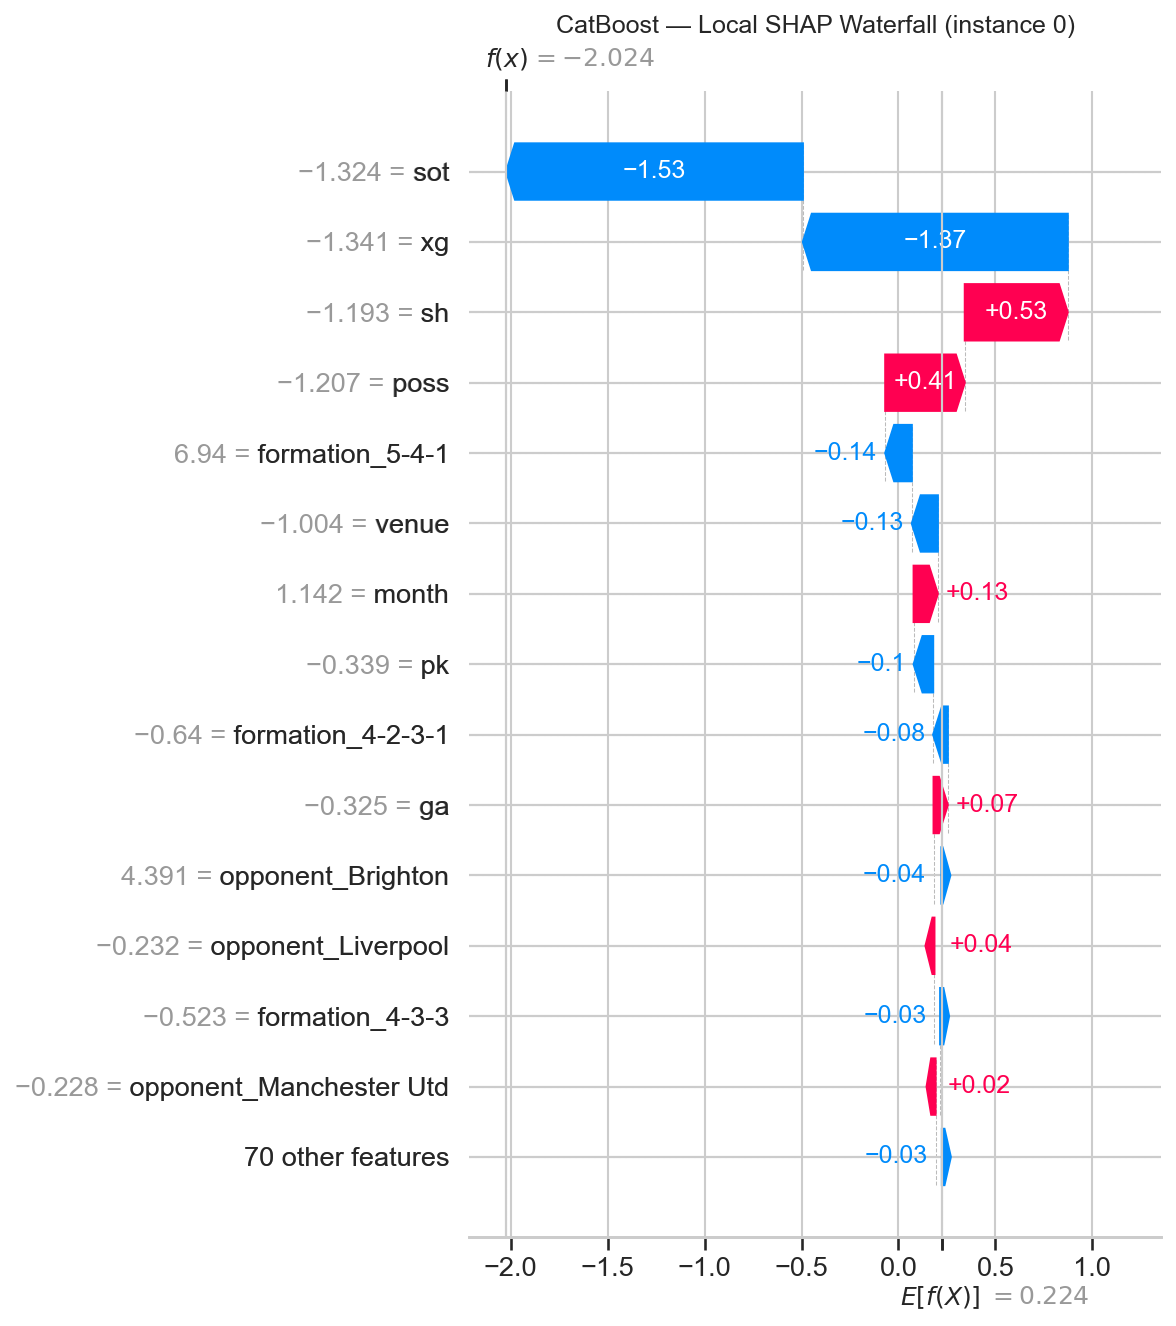

In [68]:
# 3. Local: Waterfall Plot (instance 0)

shap_exp = shap.Explanation(
    values=cat_shap_vals_plot[0],
    base_values=cat_explainer_base,
    data=X_shap_sample_cat.iloc[0].values,
    feature_names=X_shap_sample_cat.columns.tolist()
)

plt.figure()
shap.plots.waterfall(shap_exp, max_display=15, show=False)
plt.title("CatBoost — Local SHAP Waterfall (instance 0)")
plt.tight_layout()
plt.show()

<Figure size 1500x750 with 0 Axes>

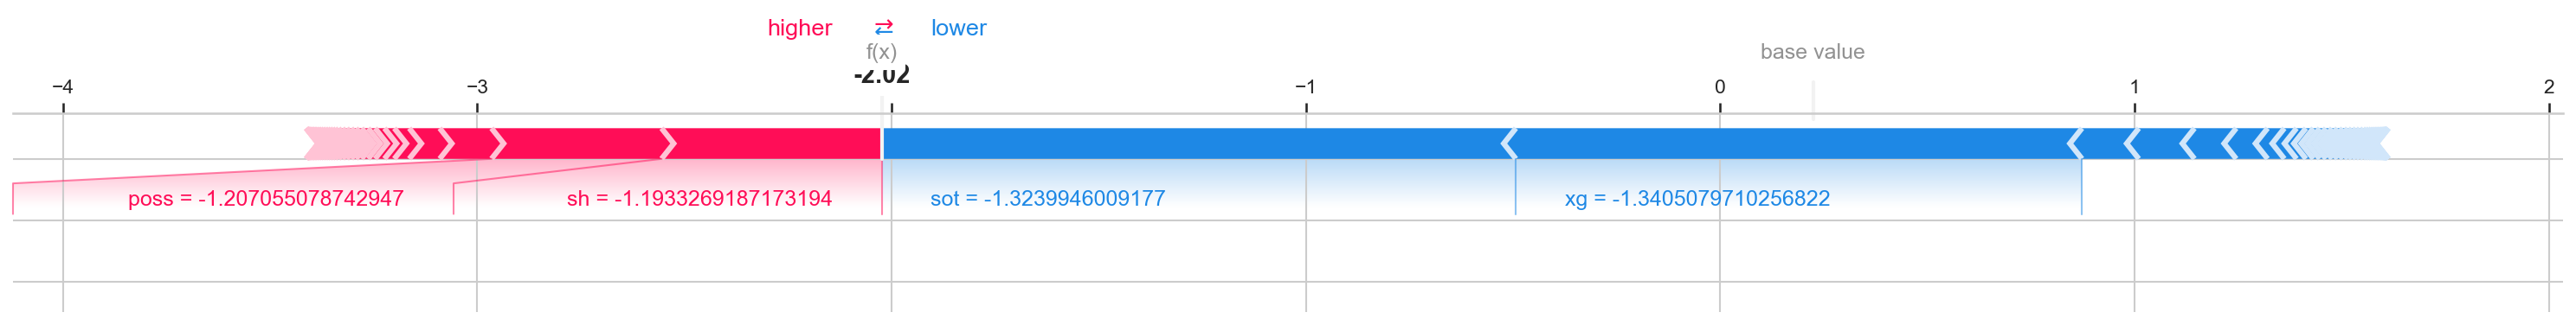

In [69]:
# 4. Local: Force Plot (instance 0) → static matplotlib

plt.figure()
shap.force_plot(
    base_value=cat_explainer_base,
    shap_values=cat_shap_vals_plot[0],
    features=X_shap_sample_cat.iloc[0],
    feature_names=X_shap_sample_cat.columns.tolist(),
    matplotlib=True,   # True = imagine statică
    show=False
)
plt.tight_layout()
plt.show()

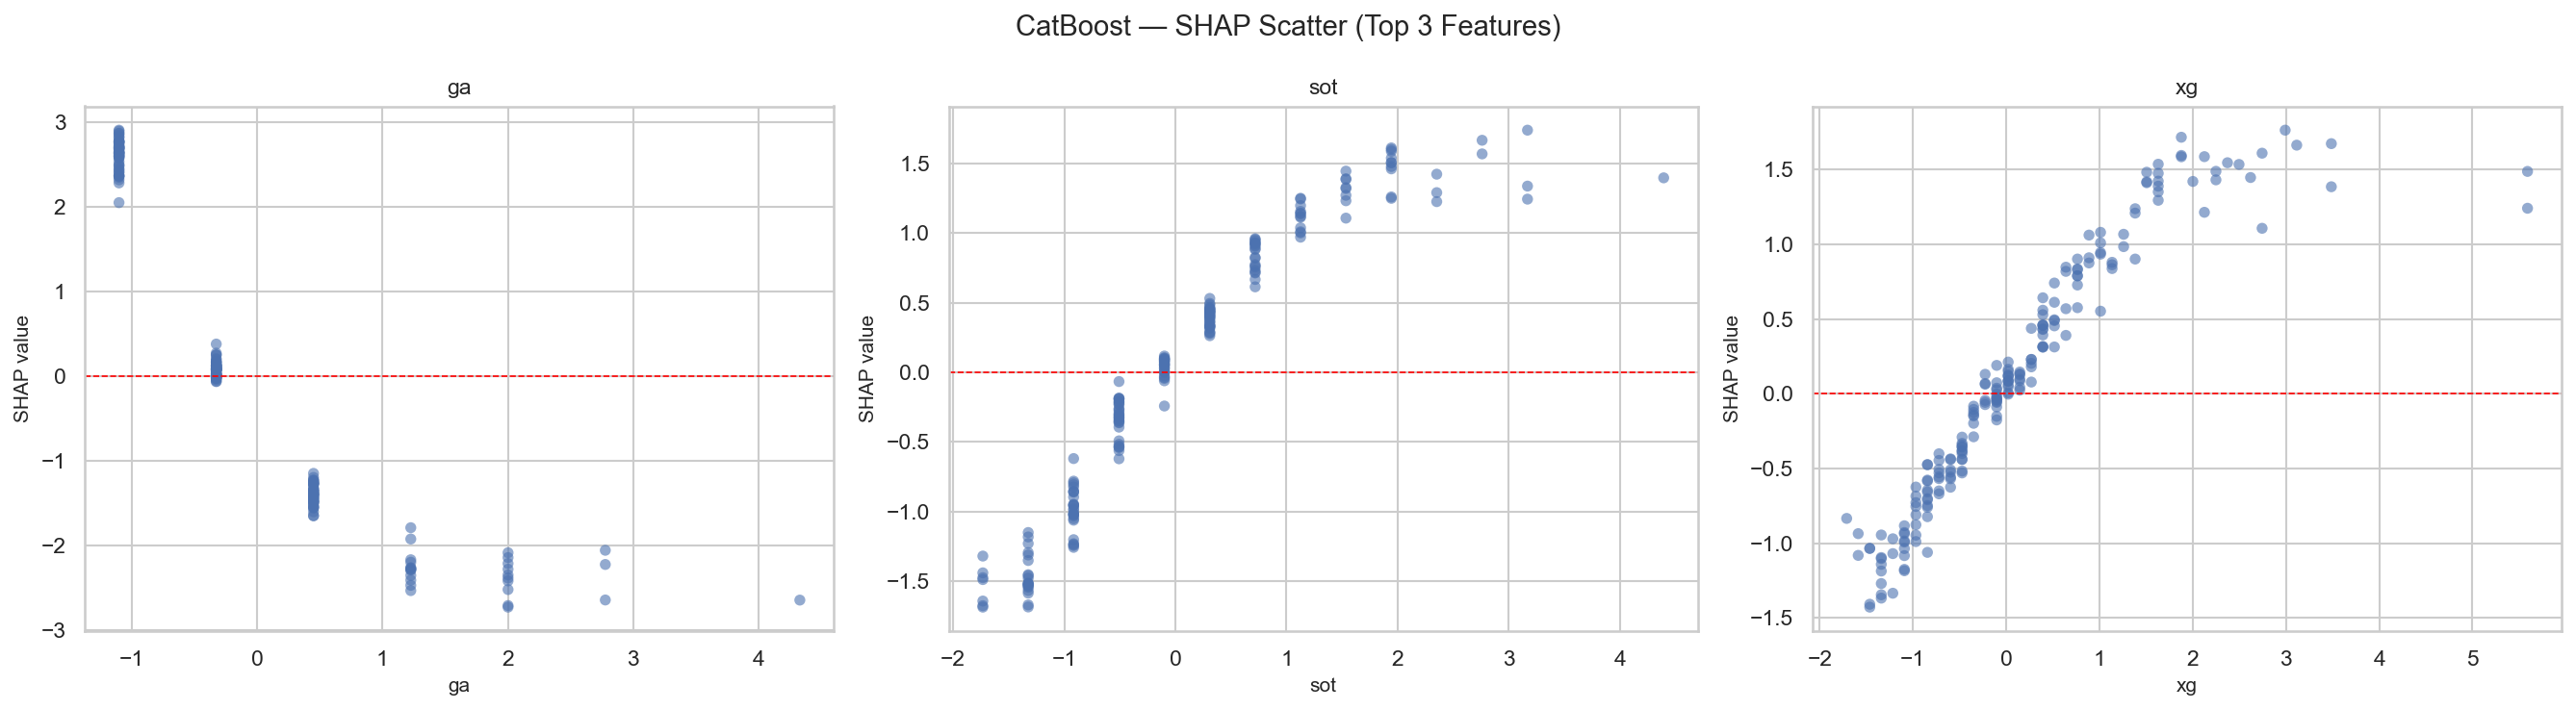

In [70]:
# 5. Scatter Plots — Top 3 Features

mean_abs_shap = np.abs(cat_shap_vals_plot).mean(axis=0)
top3_idx      = np.argsort(mean_abs_shap)[::-1][:3]
top3_features = X_shap_sample_cat.columns[top3_idx].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("CatBoost — SHAP Scatter (Top 3 Features)", fontsize=14)

for ax, feat in zip(axes, top3_features):
    col_idx = X_shap_sample_cat.columns.get_loc(feat)
    ax.scatter(
        X_shap_sample_cat[feat],
        cat_shap_vals_plot[:, col_idx],
        alpha=0.6,
        edgecolors="none",
        s=30
    )
    ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel("SHAP value", fontsize=10)
    ax.set_title(feat, fontsize=11)

plt.tight_layout()
plt.show()

In [71]:
# 9.3 Random Forest — SHAP Analysis

rf_model = tuned_models['Random Forest']  # rf_bayes.best_estimator_

# Use a sample of 200 rows to avoid kernel crash (RF is slow with SHAP)
X_shap_sample = X_test_shap.iloc[:200].reset_index(drop=True)

rf_explainer   = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_shap_sample, check_additivity=False)
rf_shap_vals   = get_shap_vals_win(rf_shap_values)

print(f"Random Forest shap_vals shape: {rf_shap_vals.shape}")

Random Forest shap_vals shape: (200, 84)


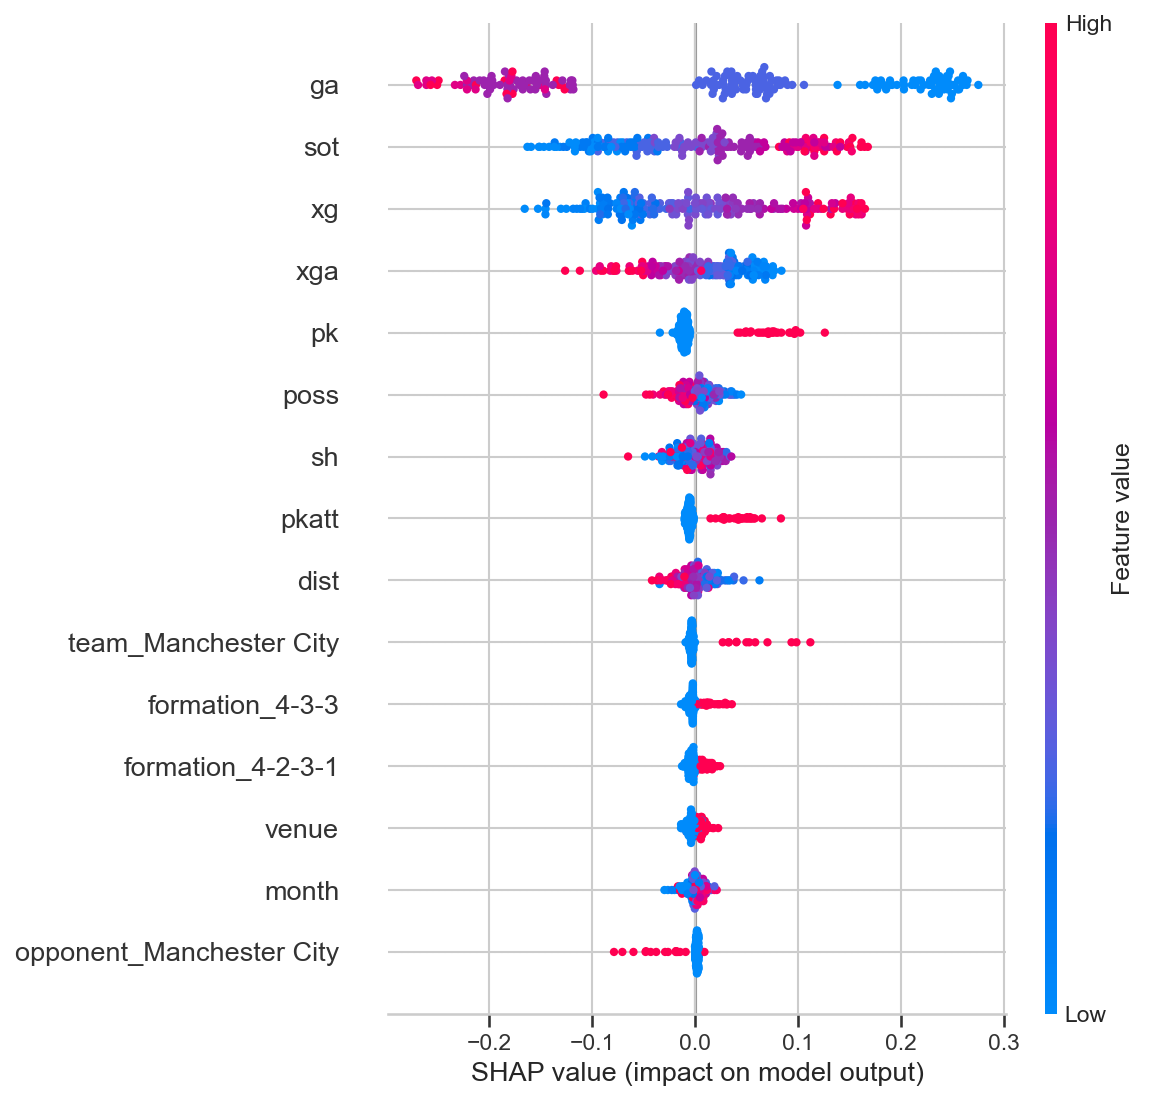

In [72]:
# Random Forest - Global: Summary Plot
shap.summary_plot(rf_shap_vals, X_shap_sample, max_display=15)

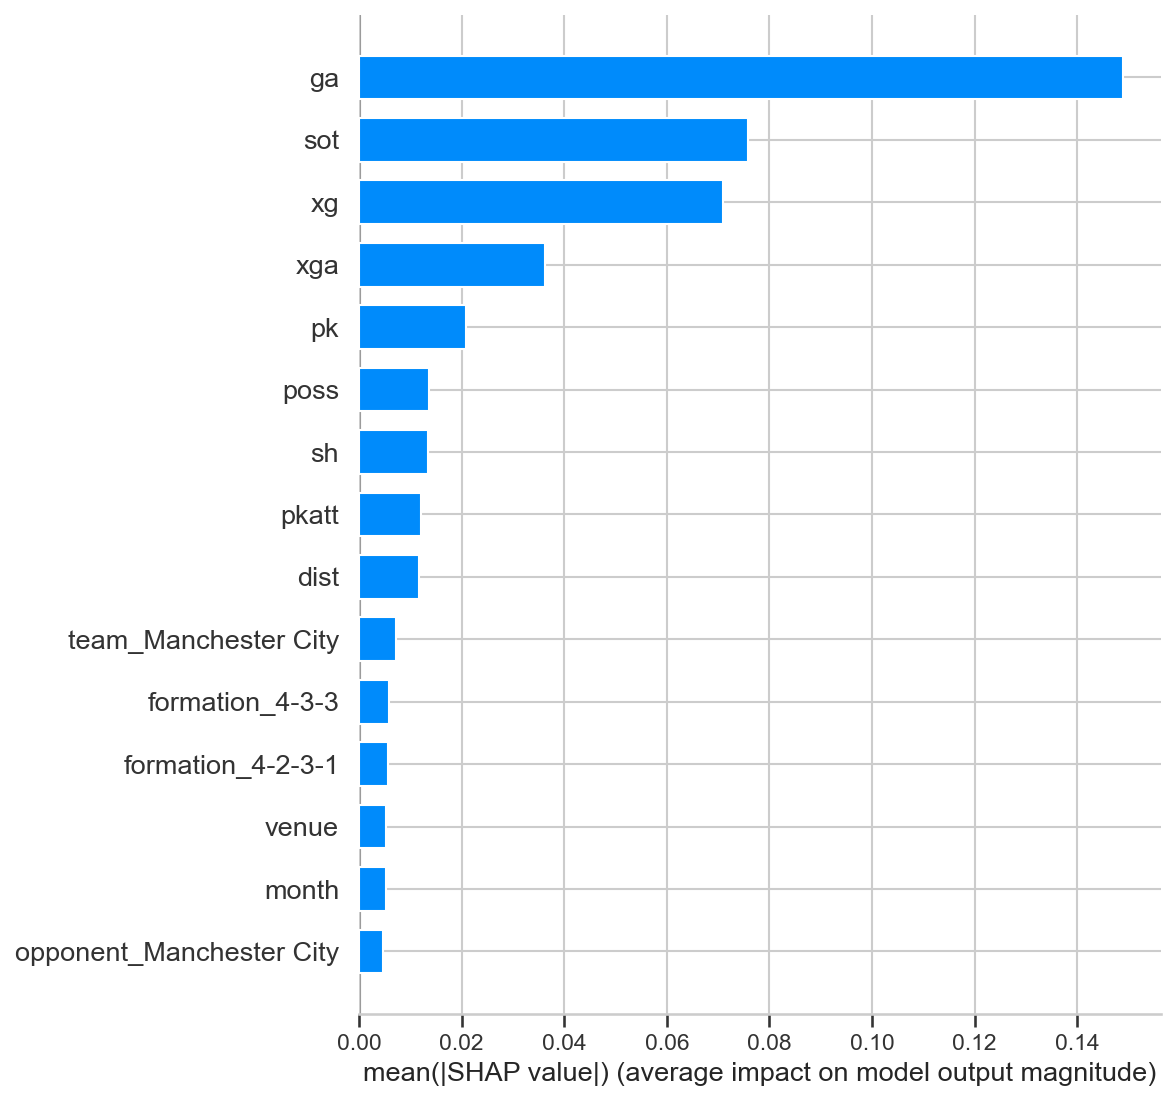

In [73]:
# Random Forest - Global: Bar Plot
shap.summary_plot(rf_shap_vals, X_shap_sample, plot_type='bar', max_display=15)

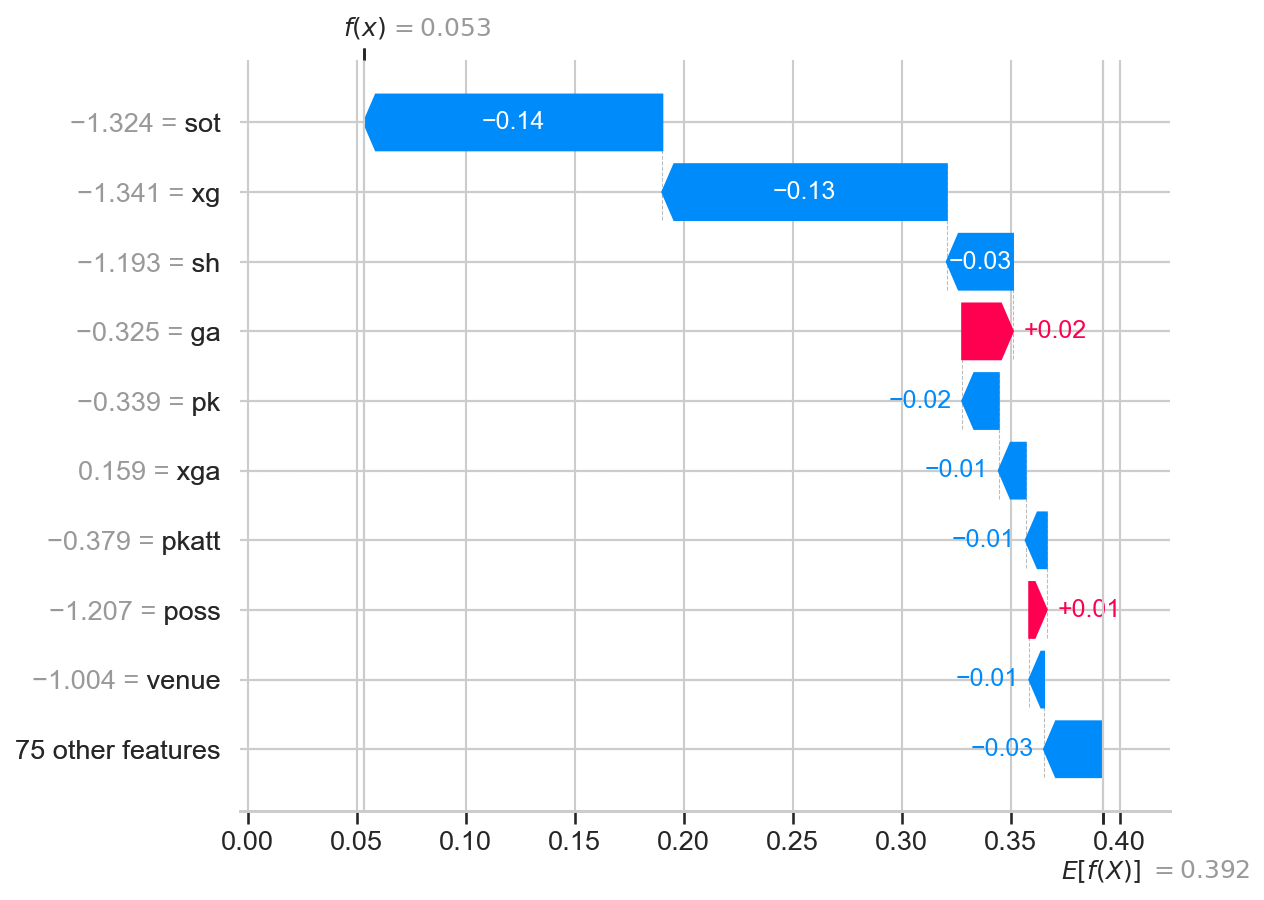

In [74]:
# Random Forest - Local: Waterfall Plot (instance 0)
rf_explanation = shap.Explanation(
    values        = rf_shap_vals[0],
    base_values   = rf_explainer.expected_value[2],
    data          = X_shap_sample.iloc[0],
    feature_names = feature_names
)
shap.plots.waterfall(rf_explanation)

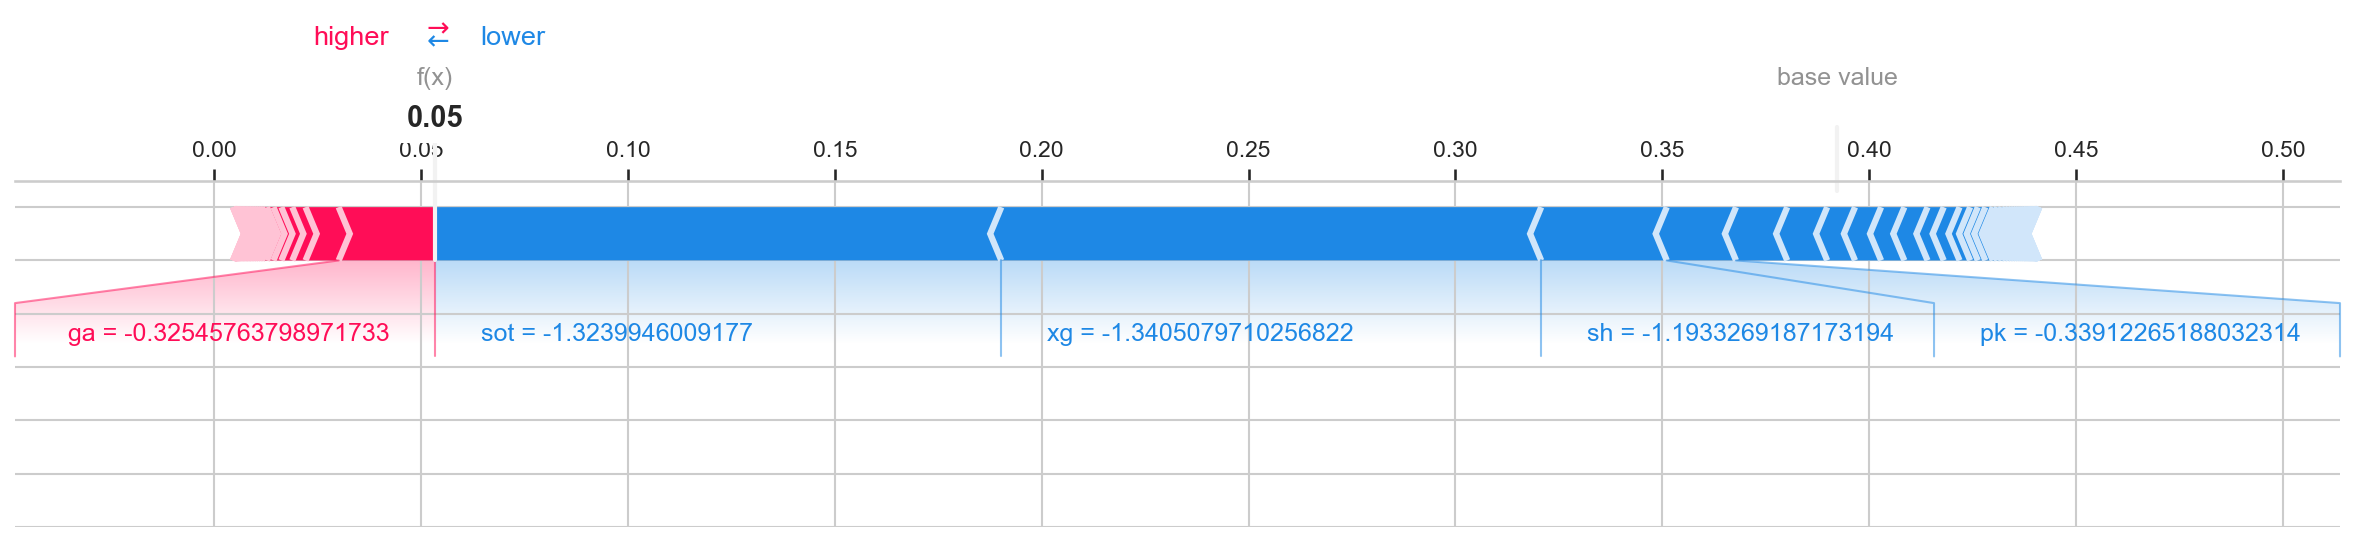

In [75]:
# Random Forest - Local: Force Plot (instance 0)
shap.force_plot(
    rf_explainer.expected_value[2],
    rf_shap_vals[0],
    X_shap_sample.iloc[0],
    matplotlib=True
)
plt.show()

Random Forest — Top 3 features: ['ga', 'sot', 'xg']


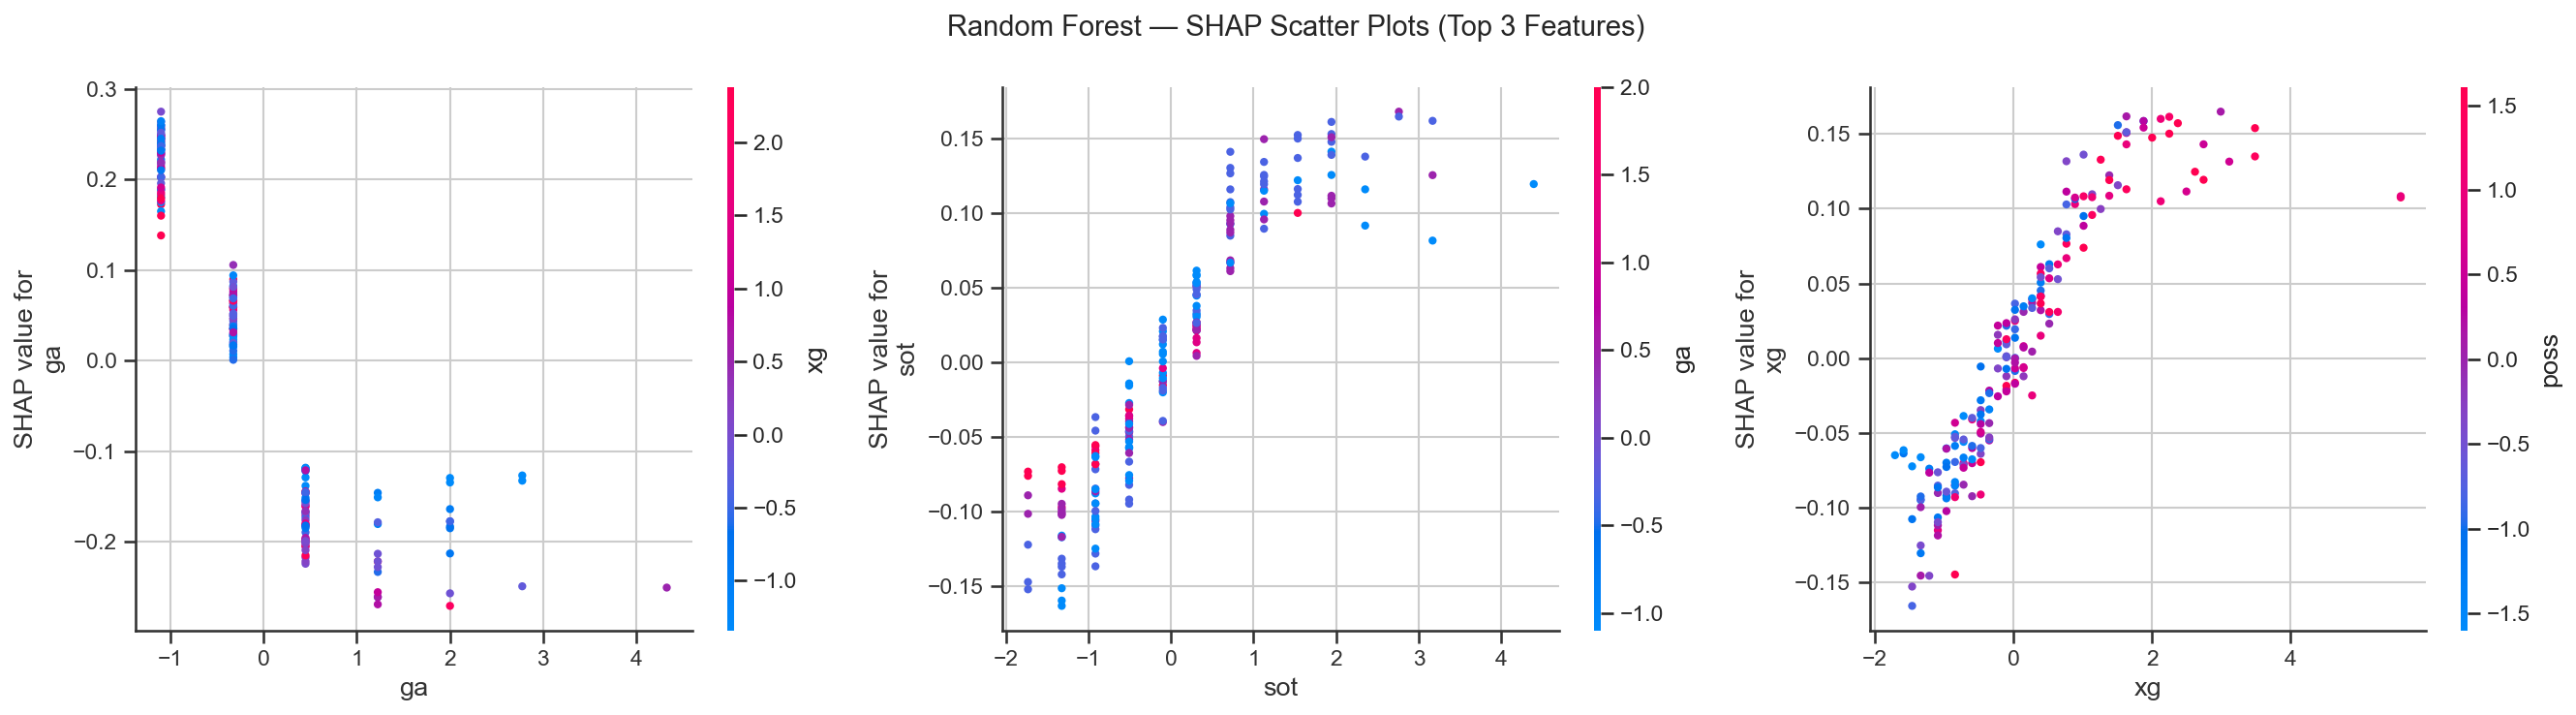

In [79]:
# Random Forest - Scatter Plots for top 3 features
rf_mean_shap = np.abs(rf_shap_vals).mean(axis=0)
rf_top3_idx  = np.argsort(rf_mean_shap)[::-1][:3]
rf_top3      = [feature_names[i] for i in rf_top3_idx]
print(f"Random Forest — Top 3 features: {rf_top3}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Random Forest — SHAP Scatter Plots (Top 3 Features)", fontsize=14)
for i, feat in enumerate(rf_top3):
    shap.dependence_plot(feat, rf_shap_vals, X_shap_sample,
                         ax=axes[i], show=False)
plt.tight_layout()
plt.show()

## 9.4 SHAP Conclusions - Model Comparison

### Top 3 most important features per model

| Rank | XGBoost | CatBoost | Random Forest |
|------|---------|----------|---------------|
| 1st  | ga      | ga       | ga            |
| 2nd  | sot     | sot      | sot           |
| 3rd  | xg      | xg       | xg            |


### Global interpretation
- **`ga` (Goals Against)** is the dominant predictor across all three models.
  Fewer goals conceded consistently pushes predictions strongly towards a **Win**.
- **`sot` (Shots on Target)** ranks second in all models - more shots on target
  increases Win probability, confirming its tactical relevance.
- **`xg` (Expected Goals)** ranks third - a high xG value signals strong
  offensive performance and correlates with winning outcomes.
- Boosting models (XGBoost, CatBoost) produce sharper, more concentrated
  SHAP distributions. Random Forest spreads importance more evenly
  across a larger number of features.
- CatBoost additionally highlights `dist` (Average Shot Distance) as relevant,
  suggesting it captures shot quality nuances that XGBoost and Random Forest
  weight less.

### Local interpretation (instance 0)
- **XGBoost** predicted **Loss** (f(x) = -2.70) - driven by very low `sot` 
  and `xg`, indicating a weak offensive performance. Blue forces dominate 
  completely.
- **CatBoost** predicted **Draw** (f(x) = 1.21) - `sot` and `xg` pushed 
  toward non-Win, but less aggressively than XGBoost. More balanced forces.
- **Random Forest** predicted **Loss/Draw** (f(x) = 0.05, near zero) - 
  `sot`, `xg`, `sh` pushed toward Loss while low `ga` slightly favored Win. 
  The score near zero reflects high uncertainty about this match outcome.
- All three models agree: **Win probability is near zero (~1-2%)** for this 
  match. The disagreement between Loss and Draw reflects a genuinely 
  ambiguous match with poor offensive stats but solid defensive numbers.

### Key takeaway
All three models consistently agree on the same top predictors - **`ga`, 
`sot`, and `xg`** - strongly validating that match outcomes in the Premier 
League are driven primarily by **defensive solidity** (goals conceded) and 
**offensive efficiency** (shots on target, expected goals), rather than 
contextual factors like venue, formation, or team identity.

In [84]:
import joblib, os
os.makedirs('../models', exist_ok=True)

# 1. Modele
joblib.dump(tuned_models, '../models/clf_tuned_models.pkl')

# 2. Scaler + date
joblib.dump(scaler,   '../models/clf_scaler.pkl')
joblib.dump(X_train,  '../models/X_train_clf.pkl')
joblib.dump(X_test,   '../models/X_test_clf.pkl')
joblib.dump(y_test_c, '../models/y_test_clf.pkl')

# 3. Rezultate
joblib.dump(classification_results, '../models/clf_baseline_results.pkl')
joblib.dump(tuned_results,          '../models/clf_tuned_results.pkl')

# 4. Learning curves
joblib.dump(lc_results_clf, '../models/lc_results_clf.pkl')

# 5. SHAP values — fix pentru numpy array
shap_clf = {
    'XGBoost':      {'vals': xgb_shap_vals if isinstance(xgb_shap_vals, np.ndarray) else xgb_shap_vals.values,
                     'base': float(xgb_explainer.expected_value[2])},
    'CatBoost':     {'vals': cat_shap_vals_plot,      
                     'base': cat_explainer_base},
    'Random Forest':{'vals': rf_shap_vals,            
                     'base': float(np.array(rf_explainer.expected_value).flatten()[0])}
}
joblib.dump(shap_clf, '../models/clf_shap.pkl')

# 6. Feature names
joblib.dump(X_train.columns.tolist(), '../models/feature_names.pkl')

print("All classification assets saved!")

All classification assets saved!
